# Seminar 04 — ACT: Action Prediction and Execution
**Student — complete TODOs and questions** · ALOHA · Colab T4 · No training

Reconstruct a pretrained action head, compare execution horizons, and implement temporal ensembling.
Assumed knowledge: attention, BC, and diffusion/flow policies from Seminars 02–03.

## Submit
Completed TODOs, numerical checks, plots/videos, metric tables, and short answers.

## 0. Setup
In Colab select **Runtime → Change runtime type → Runtime Version → 2026.07** (Python 3.12.13) and **T4 GPU**, then run the cells below. The default Python 3.13 runtime can fail while building `labmaze`, a dependency of `dm-control`.
Upload this notebook alone; installation and helper code are included.

Requires Python 3.10–3.12.

In [2]:
import os, sys, subprocess, importlib.util
# Run before importing MuJoCo / dm_control / OpenGL.
os.environ['MUJOCO_GL'] = 'egl'
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
if not (3, 10) <= sys.version_info[:2] <= (3, 12):
    raise RuntimeError('This notebook requires Python 3.10–3.12. In Colab select Runtime → Change runtime type → Runtime Version → 2026.07 (Python 3.12).')
PACKAGES = [
    'gym-aloha==0.1.4', 'gymnasium==1.2.2', 'mujoco==3.3.7', 'dm-control==1.0.34',
    'einops==0.8.1', 'safetensors==0.5.3', 'huggingface-hub==0.34.4',
    'imageio[ffmpeg]==2.37.0', 'matplotlib>=3.8,<3.11', 'pandas>=2.2,<3',
    'numpy>=1.26,<3', 'pillow>=10',
]
# Preserve Colab's matched CUDA PyTorch/torchvision installation.
if not os.environ.get('ACT_SKIP_INSTALL'):
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', *PACKAGES],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
    )
    print(result.stdout, flush=True)
    if result.returncode:
        if sys.version_info[:2] >= (3, 13):
            print('Python 3.13+: labmaze (a dm-control dependency) has no compatible '
                  'wheel on PyPI. If the log reports a labmaze build failure, select '
                  'Colab Runtime → Change runtime type → Runtime Version → 2026.07 '
                  '(Python 3.12), select T4 GPU, then rerun from the first cell.', flush=True)
        raise RuntimeError('Package installation failed. See the pip output above for the cause.')
import torch, torchvision
print('Python:', sys.version.split()[0], 'PyTorch:', torch.__version__, 'torchvision:', torchvision.__version__)
if torch.cuda.is_available():
    # print('GPU:', torch.cuda.get_device_name(0))
    torch.cuda.reset_peak_memory_stats()
else:
    print('CPU mode: numerical exercises work, but the rollout grid may be slow. In Colab select Runtime → Change runtime type → T4 GPU.')


/opt/venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(
DEPRECATION: Unexpected import of 'tabulate' after pip install started. pip 26.3 will enforce this behaviour change. Discussion can be found at https://github.com/pypa/pip/issues/13842 (/opt/venv/lib/python3.11/site-packages/torch/_dynamo/utils.py:217)

Python: 3.11.15 PyTorch: 2.7.1+cu128 torchvision: 0.22.1+cu126


### Supplied code
Run the collapsed cells unchanged: pretrained ACT, simulator, plotting, and checks.
The decoder and visual encoder are provided. No training is required.

In [3]:
#!/usr/bin/env python

# Copyright 2024 Tony Z. Zhao and The HuggingFace Inc. team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# Extracted unchanged from LeRobot 3c0a209f9fac4d2a57617e686a7f2a2309144ba2.
from __future__ import annotations
import math
from itertools import chain
from typing import Callable
import einops
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from torch import Tensor, nn
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.ops.misc import FrozenBatchNorm2d


class ACTTemporalEnsembler:
    def __init__(self, temporal_ensemble_coeff: float, chunk_size: int) -> None:
        """Temporal ensembling as described in Algorithm 2 of https://arxiv.org/abs/2304.13705.

        The weights are calculated as wᵢ = exp(-temporal_ensemble_coeff * i) where w₀ is the oldest action.
        They are then normalized to sum to 1 by dividing by Σwᵢ. Here's some intuition around how the
        coefficient works:
            - Setting it to 0 uniformly weighs all actions.
            - Setting it positive gives more weight to older actions.
            - Setting it negative gives more weight to newer actions.
        NOTE: The default value for `temporal_ensemble_coeff` used by the original ACT work is 0.01. This
        results in older actions being weighed more highly than newer actions (the experiments documented in
        https://github.com/huggingface/lerobot/pull/319 hint at why highly weighing new actions might be
        detrimental: doing so aggressively may diminish the benefits of action chunking).

        Here we use an online method for computing the average rather than caching a history of actions in
        order to compute the average offline. For a simple 1D sequence it looks something like:

        ```
        import torch

        seq = torch.linspace(8, 8.5, 100)
        print(seq)

        m = 0.01
        exp_weights = torch.exp(-m * torch.arange(len(seq)))
        print(exp_weights)

        # Calculate offline
        avg = (exp_weights * seq).sum() / exp_weights.sum()
        print("offline", avg)

        # Calculate online
        for i, item in enumerate(seq):
            if i == 0:
                avg = item
                continue
            avg *= exp_weights[:i].sum()
            avg += item * exp_weights[i]
            avg /= exp_weights[:i+1].sum()
        print("online", avg)
        ```
        """
        self.chunk_size = chunk_size
        self.ensemble_weights = torch.exp(-temporal_ensemble_coeff * torch.arange(chunk_size))
        self.ensemble_weights_cumsum = torch.cumsum(self.ensemble_weights, dim=0)
        self.reset()

    def reset(self):
        """Resets the online computation variables."""
        self.ensembled_actions = None
        # (chunk_size,) count of how many actions are in the ensemble for each time step in the sequence.
        self.ensembled_actions_count = None

    def update(self, actions: Tensor) -> Tensor:
        """
        Takes a (batch, chunk_size, action_dim) sequence of actions, update the temporal ensemble for all
        time steps, and pop/return the next batch of actions in the sequence.
        """
        self.ensemble_weights = self.ensemble_weights.to(device=actions.device)
        self.ensemble_weights_cumsum = self.ensemble_weights_cumsum.to(device=actions.device)
        if self.ensembled_actions is None:
            # Initializes `self._ensembled_action` to the sequence of actions predicted during the first
            # time step of the episode.
            self.ensembled_actions = actions.clone()
            # Note: The last dimension is unsqueeze to make sure we can broadcast properly for tensor
            # operations later.
            self.ensembled_actions_count = torch.ones(
                (self.chunk_size, 1), dtype=torch.long, device=self.ensembled_actions.device
            )
        else:
            # self.ensembled_actions will have shape (batch_size, chunk_size - 1, action_dim). Compute
            # the online update for those entries.
            self.ensembled_actions *= self.ensemble_weights_cumsum[self.ensembled_actions_count - 1]
            self.ensembled_actions += actions[:, :-1] * self.ensemble_weights[self.ensembled_actions_count]
            self.ensembled_actions /= self.ensemble_weights_cumsum[self.ensembled_actions_count]
            self.ensembled_actions_count = torch.clamp(self.ensembled_actions_count + 1, max=self.chunk_size)
            # The last action, which has no prior online average, needs to get concatenated onto the end.
            self.ensembled_actions = torch.cat([self.ensembled_actions, actions[:, -1:]], dim=1)
            self.ensembled_actions_count = torch.cat(
                [self.ensembled_actions_count, torch.ones_like(self.ensembled_actions_count[-1:])]
            )
        # "Consume" the first action.
        action, self.ensembled_actions, self.ensembled_actions_count = (
            self.ensembled_actions[:, 0],
            self.ensembled_actions[:, 1:],
            self.ensembled_actions_count[1:],
        )
        return action

class ACT(nn.Module):
    """Action Chunking Transformer: The underlying neural network for ACTPolicy.

    Note: In this code we use the terms `vae_encoder`, 'encoder', `decoder`. The meanings are as follows.
        - The `vae_encoder` is, as per the literature around variational auto-encoders (VAE), the part of the
          model that encodes the target data (a sequence of actions), and the condition (the robot
          joint-space).
        - A transformer with an `encoder` (not the VAE encoder) and `decoder` (not the VAE decoder) with
          cross-attention is used as the VAE decoder. For these terms, we drop the `vae_` prefix because we
          have an option to train this model without the variational objective (in which case we drop the
          `vae_encoder` altogether, and nothing about this model has anything to do with a VAE).

                                 Transformer
                                 Used alone for inference
                                 (acts as VAE decoder
                                  during training)
                                ┌───────────────────────┐
                                │             Outputs   │
                                │                ▲      │
                                │     ┌─────►┌───────┐  │
                   ┌──────┐     │     │      │Transf.│  │
                   │      │     │     ├─────►│decoder│  │
              ┌────┴────┐ │     │     │      │       │  │
              │         │ │     │ ┌───┴───┬─►│       │  │
              │ VAE     │ │     │ │       │  └───────┘  │
              │ encoder │ │     │ │Transf.│             │
              │         │ │     │ │encoder│             │
              └───▲─────┘ │     │ │       │             │
                  │       │     │ └▲──▲─▲─┘             │
                  │       │     │  │  │ │               │
                inputs    └─────┼──┘  │ image emb.      │
                                │    state emb.         │
                                └───────────────────────┘
    """

    def __init__(self, config: ACTConfig):
        # BERT style VAE encoder with input tokens [cls, robot_state, *action_sequence].
        # The cls token forms parameters of the latent's distribution (like this [*means, *log_variances]).
        super().__init__()
        self.config = config

        if self.config.use_vae:
            self.vae_encoder = ACTEncoder(config, is_vae_encoder=True)
            self.vae_encoder_cls_embed = nn.Embedding(1, config.dim_model)
            # Projection layer for joint-space configuration to hidden dimension.
            if self.config.robot_state_feature:
                self.vae_encoder_robot_state_input_proj = nn.Linear(
                    self.config.robot_state_feature.shape[0], config.dim_model
                )
            # Projection layer for action (joint-space target) to hidden dimension.
            self.vae_encoder_action_input_proj = nn.Linear(
                self.config.action_feature.shape[0],
                config.dim_model,
            )
            # Projection layer from the VAE encoder's output to the latent distribution's parameter space.
            self.vae_encoder_latent_output_proj = nn.Linear(config.dim_model, config.latent_dim * 2)
            # Fixed sinusoidal positional embedding for the input to the VAE encoder. Unsqueeze for batch
            # dimension.
            num_input_token_encoder = 1 + config.chunk_size
            if self.config.robot_state_feature:
                num_input_token_encoder += 1
            self.register_buffer(
                "vae_encoder_pos_enc",
                create_sinusoidal_pos_embedding(num_input_token_encoder, config.dim_model).unsqueeze(0),
            )

        # Backbone for image feature extraction.
        if self.config.image_features:
            backbone_model = getattr(torchvision.models, config.vision_backbone)(
                replace_stride_with_dilation=[False, False, config.replace_final_stride_with_dilation],
                weights=config.pretrained_backbone_weights,
                norm_layer=FrozenBatchNorm2d,
            )
            # Note: The assumption here is that we are using a ResNet model (and hence layer4 is the final
            # feature map).
            # Note: The forward method of this returns a dict: {"feature_map": output}.
            self.backbone = IntermediateLayerGetter(backbone_model, return_layers={"layer4": "feature_map"})

        # Transformer (acts as VAE decoder when training with the variational objective).
        self.encoder = ACTEncoder(config)
        self.decoder = ACTDecoder(config)

        # Transformer encoder input projections. The tokens will be structured like
        # [latent, (robot_state), (env_state), (image_feature_map_pixels)].
        if self.config.robot_state_feature:
            self.encoder_robot_state_input_proj = nn.Linear(
                self.config.robot_state_feature.shape[0], config.dim_model
            )
        if self.config.env_state_feature:
            self.encoder_env_state_input_proj = nn.Linear(
                self.config.env_state_feature.shape[0], config.dim_model
            )
        self.encoder_latent_input_proj = nn.Linear(config.latent_dim, config.dim_model)
        if self.config.image_features:
            self.encoder_img_feat_input_proj = nn.Conv2d(
                backbone_model.fc.in_features, config.dim_model, kernel_size=1
            )
        # Transformer encoder positional embeddings.
        n_1d_tokens = 1  # for the latent
        if self.config.robot_state_feature:
            n_1d_tokens += 1
        if self.config.env_state_feature:
            n_1d_tokens += 1
        self.encoder_1d_feature_pos_embed = nn.Embedding(n_1d_tokens, config.dim_model)
        if self.config.image_features:
            self.encoder_cam_feat_pos_embed = ACTSinusoidalPositionEmbedding2d(config.dim_model // 2)

        # Transformer decoder.
        # Learnable positional embedding for the transformer's decoder (in the style of DETR object queries).
        self.decoder_pos_embed = nn.Embedding(config.chunk_size, config.dim_model)

        # Final action regression head on the output of the transformer's decoder.
        self.action_head = nn.Linear(config.dim_model, self.config.action_feature.shape[0])

        self._reset_parameters()

    def _reset_parameters(self):
        """Xavier-uniform initialization of the transformer parameters as in the original code."""
        for p in chain(self.encoder.parameters(), self.decoder.parameters()):
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, batch: dict[str, Tensor]) -> tuple[Tensor, tuple[Tensor, Tensor] | tuple[None, None]]:
        """A forward pass through the Action Chunking Transformer (with optional VAE encoder).

        `batch` should have the following structure:
        {
            [robot_state_feature] (optional): (B, state_dim) batch of robot states.

            [image_features]: (B, n_cameras, C, H, W) batch of images.
                AND/OR
            [env_state_feature]: (B, env_dim) batch of environment states.

            [action_feature] (optional, only if training with VAE): (B, chunk_size, action dim) batch of actions.
        }

        Returns:
            (B, chunk_size, action_dim) batch of action sequences
            Tuple containing the latent PDF's parameters (mean, log(σ²)) both as (B, L) tensors where L is the
            latent dimension.
        """
        if self.config.use_vae and self.training:
            assert (
                "action" in batch
            ), "actions must be provided when using the variational objective in training mode."

        batch_size = (
            batch["observation.images"]
            if "observation.images" in batch
            else batch["observation.environment_state"]
        ).shape[0]

        # Prepare the latent for input to the transformer encoder.
        if self.config.use_vae and "action" in batch:
            # Prepare the input to the VAE encoder: [cls, *joint_space_configuration, *action_sequence].
            cls_embed = einops.repeat(
                self.vae_encoder_cls_embed.weight, "1 d -> b 1 d", b=batch_size
            )  # (B, 1, D)
            if self.config.robot_state_feature:
                robot_state_embed = self.vae_encoder_robot_state_input_proj(batch["observation.state"])
                robot_state_embed = robot_state_embed.unsqueeze(1)  # (B, 1, D)
            action_embed = self.vae_encoder_action_input_proj(batch["action"])  # (B, S, D)

            if self.config.robot_state_feature:
                vae_encoder_input = [cls_embed, robot_state_embed, action_embed]  # (B, S+2, D)
            else:
                vae_encoder_input = [cls_embed, action_embed]
            vae_encoder_input = torch.cat(vae_encoder_input, axis=1)

            # Prepare fixed positional embedding.
            # Note: detach() shouldn't be necessary but leaving it the same as the original code just in case.
            pos_embed = self.vae_encoder_pos_enc.clone().detach()  # (1, S+2, D)

            # Prepare key padding mask for the transformer encoder. We have 1 or 2 extra tokens at the start of the
            # sequence depending whether we use the input states or not (cls and robot state)
            # False means not a padding token.
            cls_joint_is_pad = torch.full(
                (batch_size, 2 if self.config.robot_state_feature else 1),
                False,
                device=batch["observation.state"].device,
            )
            key_padding_mask = torch.cat(
                [cls_joint_is_pad, batch["action_is_pad"]], axis=1
            )  # (bs, seq+1 or 2)

            # Forward pass through VAE encoder to get the latent PDF parameters.
            cls_token_out = self.vae_encoder(
                vae_encoder_input.permute(1, 0, 2),
                pos_embed=pos_embed.permute(1, 0, 2),
                key_padding_mask=key_padding_mask,
            )[0]  # select the class token, with shape (B, D)
            latent_pdf_params = self.vae_encoder_latent_output_proj(cls_token_out)
            mu = latent_pdf_params[:, : self.config.latent_dim]
            # This is 2log(sigma). Done this way to match the original implementation.
            log_sigma_x2 = latent_pdf_params[:, self.config.latent_dim :]

            # Sample the latent with the reparameterization trick.
            latent_sample = mu + log_sigma_x2.div(2).exp() * torch.randn_like(mu)
        else:
            # When not using the VAE encoder, we set the latent to be all zeros.
            mu = log_sigma_x2 = None
            # TODO(rcadene, alexander-soare): remove call to `.to` to speedup forward ; precompute and use buffer
            latent_sample = torch.zeros([batch_size, self.config.latent_dim], dtype=torch.float32).to(
                batch["observation.state"].device
            )

        # Prepare transformer encoder inputs.
        encoder_in_tokens = [self.encoder_latent_input_proj(latent_sample)]
        encoder_in_pos_embed = list(self.encoder_1d_feature_pos_embed.weight.unsqueeze(1))
        # Robot state token.
        if self.config.robot_state_feature:
            encoder_in_tokens.append(self.encoder_robot_state_input_proj(batch["observation.state"]))
        # Environment state token.
        if self.config.env_state_feature:
            encoder_in_tokens.append(
                self.encoder_env_state_input_proj(batch["observation.environment_state"])
            )

        # Camera observation features and positional embeddings.
        if self.config.image_features:
            all_cam_features = []
            all_cam_pos_embeds = []

            for cam_index in range(batch["observation.images"].shape[-4]):
                cam_features = self.backbone(batch["observation.images"][:, cam_index])["feature_map"]
                # TODO(rcadene, alexander-soare): remove call to `.to` to speedup forward ; precompute and use
                # buffer
                cam_pos_embed = self.encoder_cam_feat_pos_embed(cam_features).to(dtype=cam_features.dtype)
                cam_features = self.encoder_img_feat_input_proj(cam_features)  # (B, C, h, w)
                all_cam_features.append(cam_features)
                all_cam_pos_embeds.append(cam_pos_embed)
            # Concatenate camera observation feature maps and positional embeddings along the width dimension,
            # and move to (sequence, batch, dim).
            all_cam_features = torch.cat(all_cam_features, axis=-1)
            encoder_in_tokens.extend(einops.rearrange(all_cam_features, "b c h w -> (h w) b c"))
            all_cam_pos_embeds = torch.cat(all_cam_pos_embeds, axis=-1)
            encoder_in_pos_embed.extend(einops.rearrange(all_cam_pos_embeds, "b c h w -> (h w) b c"))

        # Stack all tokens along the sequence dimension.
        encoder_in_tokens = torch.stack(encoder_in_tokens, axis=0)
        encoder_in_pos_embed = torch.stack(encoder_in_pos_embed, axis=0)

        # Forward pass through the transformer modules.
        encoder_out = self.encoder(encoder_in_tokens, pos_embed=encoder_in_pos_embed)
        # TODO(rcadene, alexander-soare): remove call to `device` ; precompute and use buffer
        decoder_in = torch.zeros(
            (self.config.chunk_size, batch_size, self.config.dim_model),
            dtype=encoder_in_pos_embed.dtype,
            device=encoder_in_pos_embed.device,
        )
        decoder_out = self.decoder(
            decoder_in,
            encoder_out,
            encoder_pos_embed=encoder_in_pos_embed,
            decoder_pos_embed=self.decoder_pos_embed.weight.unsqueeze(1),
        )

        # Move back to (B, S, C).
        decoder_out = decoder_out.transpose(0, 1)

        actions = self.action_head(decoder_out)

        return actions, (mu, log_sigma_x2)

class ACTEncoder(nn.Module):
    """Convenience module for running multiple encoder layers, maybe followed by normalization."""

    def __init__(self, config: ACTConfig, is_vae_encoder: bool = False):
        super().__init__()
        self.is_vae_encoder = is_vae_encoder
        num_layers = config.n_vae_encoder_layers if self.is_vae_encoder else config.n_encoder_layers
        self.layers = nn.ModuleList([ACTEncoderLayer(config) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(config.dim_model) if config.pre_norm else nn.Identity()

    def forward(
        self, x: Tensor, pos_embed: Tensor | None = None, key_padding_mask: Tensor | None = None
    ) -> Tensor:
        for layer in self.layers:
            x = layer(x, pos_embed=pos_embed, key_padding_mask=key_padding_mask)
        x = self.norm(x)
        return x

class ACTEncoderLayer(nn.Module):
    def __init__(self, config: ACTConfig):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(config.dim_model, config.n_heads, dropout=config.dropout)

        # Feed forward layers.
        self.linear1 = nn.Linear(config.dim_model, config.dim_feedforward)
        self.dropout = nn.Dropout(config.dropout)
        self.linear2 = nn.Linear(config.dim_feedforward, config.dim_model)

        self.norm1 = nn.LayerNorm(config.dim_model)
        self.norm2 = nn.LayerNorm(config.dim_model)
        self.dropout1 = nn.Dropout(config.dropout)
        self.dropout2 = nn.Dropout(config.dropout)

        self.activation = get_activation_fn(config.feedforward_activation)
        self.pre_norm = config.pre_norm

    def forward(self, x, pos_embed: Tensor | None = None, key_padding_mask: Tensor | None = None) -> Tensor:
        skip = x
        if self.pre_norm:
            x = self.norm1(x)
        q = k = x if pos_embed is None else x + pos_embed
        x = self.self_attn(q, k, value=x, key_padding_mask=key_padding_mask)
        x = x[0]  # note: [0] to select just the output, not the attention weights
        x = skip + self.dropout1(x)
        if self.pre_norm:
            skip = x
            x = self.norm2(x)
        else:
            x = self.norm1(x)
            skip = x
        x = self.linear2(self.dropout(self.activation(self.linear1(x))))
        x = skip + self.dropout2(x)
        if not self.pre_norm:
            x = self.norm2(x)
        return x

class ACTDecoder(nn.Module):
    def __init__(self, config: ACTConfig):
        """Convenience module for running multiple decoder layers followed by normalization."""
        super().__init__()
        self.layers = nn.ModuleList([ACTDecoderLayer(config) for _ in range(config.n_decoder_layers)])
        self.norm = nn.LayerNorm(config.dim_model)

    def forward(
        self,
        x: Tensor,
        encoder_out: Tensor,
        decoder_pos_embed: Tensor | None = None,
        encoder_pos_embed: Tensor | None = None,
    ) -> Tensor:
        for layer in self.layers:
            x = layer(
                x, encoder_out, decoder_pos_embed=decoder_pos_embed, encoder_pos_embed=encoder_pos_embed
            )
        if self.norm is not None:
            x = self.norm(x)
        return x

class ACTDecoderLayer(nn.Module):
    def __init__(self, config: ACTConfig):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(config.dim_model, config.n_heads, dropout=config.dropout)
        self.multihead_attn = nn.MultiheadAttention(config.dim_model, config.n_heads, dropout=config.dropout)

        # Feed forward layers.
        self.linear1 = nn.Linear(config.dim_model, config.dim_feedforward)
        self.dropout = nn.Dropout(config.dropout)
        self.linear2 = nn.Linear(config.dim_feedforward, config.dim_model)

        self.norm1 = nn.LayerNorm(config.dim_model)
        self.norm2 = nn.LayerNorm(config.dim_model)
        self.norm3 = nn.LayerNorm(config.dim_model)
        self.dropout1 = nn.Dropout(config.dropout)
        self.dropout2 = nn.Dropout(config.dropout)
        self.dropout3 = nn.Dropout(config.dropout)

        self.activation = get_activation_fn(config.feedforward_activation)
        self.pre_norm = config.pre_norm

    def maybe_add_pos_embed(self, tensor: Tensor, pos_embed: Tensor | None) -> Tensor:
        return tensor if pos_embed is None else tensor + pos_embed

    def forward(
        self,
        x: Tensor,
        encoder_out: Tensor,
        decoder_pos_embed: Tensor | None = None,
        encoder_pos_embed: Tensor | None = None,
    ) -> Tensor:
        """
        Args:
            x: (Decoder Sequence, Batch, Channel) tensor of input tokens.
            encoder_out: (Encoder Sequence, B, C) output features from the last layer of the encoder we are
                cross-attending with.
            decoder_pos_embed: (ES, 1, C) positional embedding for keys (from the encoder).
            encoder_pos_embed: (DS, 1, C) Positional_embedding for the queries (from the decoder).
        Returns:
            (DS, B, C) tensor of decoder output features.
        """
        skip = x
        if self.pre_norm:
            x = self.norm1(x)
        q = k = self.maybe_add_pos_embed(x, decoder_pos_embed)
        x = self.self_attn(q, k, value=x)[0]  # select just the output, not the attention weights
        x = skip + self.dropout1(x)
        if self.pre_norm:
            skip = x
            x = self.norm2(x)
        else:
            x = self.norm1(x)
            skip = x
        x = self.multihead_attn(
            query=self.maybe_add_pos_embed(x, decoder_pos_embed),
            key=self.maybe_add_pos_embed(encoder_out, encoder_pos_embed),
            value=encoder_out,
        )[0]  # select just the output, not the attention weights
        x = skip + self.dropout2(x)
        if self.pre_norm:
            skip = x
            x = self.norm3(x)
        else:
            x = self.norm2(x)
            skip = x
        x = self.linear2(self.dropout(self.activation(self.linear1(x))))
        x = skip + self.dropout3(x)
        if not self.pre_norm:
            x = self.norm3(x)
        return x

def create_sinusoidal_pos_embedding(num_positions: int, dimension: int) -> Tensor:
    """1D sinusoidal positional embeddings as in Attention is All You Need.

    Args:
        num_positions: Number of token positions required.
    Returns: (num_positions, dimension) position embeddings (the first dimension is the batch dimension).

    """

    def get_position_angle_vec(position):
        return [position / np.power(10000, 2 * (hid_j // 2) / dimension) for hid_j in range(dimension)]

    sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(num_positions)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # dim 2i
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # dim 2i+1
    return torch.from_numpy(sinusoid_table).float()

class ACTSinusoidalPositionEmbedding2d(nn.Module):
    """2D sinusoidal positional embeddings similar to what's presented in Attention Is All You Need.

    The variation is that the position indices are normalized in [0, 2π] (not quite: the lower bound is 1/H
    for the vertical direction, and 1/W for the horizontal direction.
    """

    def __init__(self, dimension: int):
        """
        Args:
            dimension: The desired dimension of the embeddings.
        """
        super().__init__()
        self.dimension = dimension
        self._two_pi = 2 * math.pi
        self._eps = 1e-6
        # Inverse "common ratio" for the geometric progression in sinusoid frequencies.
        self._temperature = 10000

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x: A (B, C, H, W) batch of 2D feature map to generate the embeddings for.
        Returns:
            A (1, C, H, W) batch of corresponding sinusoidal positional embeddings.
        """
        not_mask = torch.ones_like(x[0, :1])  # (1, H, W)
        # Note: These are like range(1, H+1) and range(1, W+1) respectively, but in most implementations
        # they would be range(0, H) and range(0, W). Keeping it at as is to match the original code.
        y_range = not_mask.cumsum(1, dtype=torch.float32)
        x_range = not_mask.cumsum(2, dtype=torch.float32)

        # "Normalize" the position index such that it ranges in [0, 2π].
        # Note: Adding epsilon on the denominator should not be needed as all values of y_embed and x_range
        # are non-zero by construction. This is an artifact of the original code.
        y_range = y_range / (y_range[:, -1:, :] + self._eps) * self._two_pi
        x_range = x_range / (x_range[:, :, -1:] + self._eps) * self._two_pi

        inverse_frequency = self._temperature ** (
            2 * (torch.arange(self.dimension, dtype=torch.float32, device=x.device) // 2) / self.dimension
        )

        x_range = x_range.unsqueeze(-1) / inverse_frequency  # (1, H, W, 1)
        y_range = y_range.unsqueeze(-1) / inverse_frequency  # (1, H, W, 1)

        # Note: this stack then flatten operation results in interleaved sine and cosine terms.
        # pos_embed_x and pos_embed_y are (1, H, W, C // 2).
        pos_embed_x = torch.stack((x_range[..., 0::2].sin(), x_range[..., 1::2].cos()), dim=-1).flatten(3)
        pos_embed_y = torch.stack((y_range[..., 0::2].sin(), y_range[..., 1::2].cos()), dim=-1).flatten(3)
        pos_embed = torch.cat((pos_embed_y, pos_embed_x), dim=3).permute(0, 3, 1, 2)  # (1, C, H, W)

        return pos_embed

def get_activation_fn(activation: str) -> Callable:
    """Return an activation function given a string."""
    if activation == "relu":
        return F.relu
    if activation == "gelu":
        return F.gelu
    if activation == "glu":
        return F.glu
    raise RuntimeError(f"activation should be relu/gelu/glu, not {activation}.")

In [4]:
"""Supplied notebook utilities. Embedded by build_notebooks.py; no local imports required."""
import copy
import hashlib
import json
import time
from pathlib import Path
from types import SimpleNamespace
from collections import deque

import gymnasium as gym
import gym_aloha
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Video, HTML
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

MODEL_ID = 'lerobot/act_aloha_sim_transfer_cube_human'
MODEL_REVISION = 'ba73b2766f1371cdc133ca4efb97eb090d744625'
SOURCE_REVISION = '3c0a209f9fac4d2a57617e686a7f2a2309144ba2'
PERTURB_DX = 0.07  # metres along world x, applied at control step 20
RESULTS = Path('seminar04_runs')
RESULTS.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(2)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
JOINT_NAMES = [f'{side}/{name}' for side in ('left', 'right')
               for name in ('waist', 'shoulder', 'elbow', 'forearm_roll', 'wrist_angle', 'wrist_rotate', 'gripper')]
ARM_INDICES = [i for i in range(14) if i not in (6, 13)]


def load_pretrained():
    config_path = hf_hub_download(MODEL_ID, 'config.json', revision=MODEL_REVISION)
    weights_path = hf_hub_download(MODEL_ID, 'model.safetensors', revision=MODEL_REVISION)
    c = json.loads(Path(config_path).read_text())
    c['robot_state_feature'] = SimpleNamespace(shape=(14,))
    c['action_feature'] = SimpleNamespace(shape=(14,))
    c['env_state_feature'] = None
    c['image_features'] = {'observation.images.top': SimpleNamespace(shape=(3, 480, 640))}
    # All backbone parameters come from the ACT checkpoint, not a second download.
    c['pretrained_backbone_weights'] = None
    config = SimpleNamespace(**c)
    weights = load_file(weights_path)
    model = ACT(config).eval().to(DEVICE)
    model.load_state_dict({k.removeprefix('model.'): v for k, v in weights.items()
                           if k.startswith('model.')}, strict=True)
    stats = {k: v.to(DEVICE) for k, v in weights.items() if not k.startswith('model.')}
    expected = {f'{prefix}.{field}' for prefix in (
        'normalize_inputs.buffer_observation_images_top',
        'normalize_inputs.buffer_observation_state', 'normalize_targets.buffer_action',
        'unnormalize_outputs.buffer_action') for field in ('mean', 'std')}
    assert set(stats) == expected, 'Unexpected normalization schema: inspect before proceeding.'
    for key, value in stats.items():
        assert torch.isfinite(value).all(), key
        if key.endswith('std'):
            assert (value > 0).all(), key
    print(f'Checkpoint: {MODEL_ID}@{MODEL_REVISION}\nStrict parameter loading passed; {DEVICE=}')
    print(f'H={config.chunk_size}, D={config.dim_model}, action_dim=14; no training')
    return model, stats


def normalize_observation(obs, stats):
    image = torch.as_tensor(obs['pixels']['top'].copy(), device=DEVICE).permute(2, 0, 1).float() / 255
    state = torch.as_tensor(obs['agent_pos'], dtype=torch.float32, device=DEVICE)
    def norm(x, name):
        return (x - stats[name + '.mean']) / (stats[name + '.std'] + 1e-8)
    return {'observation.images': norm(image, 'normalize_inputs.buffer_observation_images_top')[None, None],
            'observation.state': norm(state, 'normalize_inputs.buffer_observation_state')[None]}


def reference_denormalize(x, stats):
    return x * stats['unnormalize_outputs.buffer_action.std'] + stats['unnormalize_outputs.buffer_action.mean']


@torch.inference_mode()
def capture_fixture(model, batch):
    captured = {}
    def pre_hook(module, args, kwargs):
        captured['memory'] = args[1].detach().clone()  # [N,B,D]
        captured['positions'] = kwargs['encoder_pos_embed'].detach().clone()
    def post_hook(module, args, output):
        captured['features'] = output.transpose(0, 1).detach().clone()
    h1 = model.decoder.register_forward_pre_hook(pre_hook, with_kwargs=True)
    h2 = model.decoder.register_forward_hook(post_hook)
    try:
        captured['normalized'] = model(batch)[0].detach().clone()
    finally:
        h1.remove(); h2.remove()
    return captured


class ReferenceHead(nn.Module):
    """A supplied fallback and independent full-model reference remain available."""
    def __init__(self, model):
        super().__init__()
        self.decoder = model.decoder
        self.queries = model.decoder_pos_embed
        self.projection = model.action_head
    def forward(self, memory, positions):
        h, d = self.queries.weight.shape
        x = memory.new_zeros(h, memory.shape[1], d)
        f = self.decoder(x, memory, encoder_pos_embed=positions,
                         decoder_pos_embed=self.queries.weight[:, None]).transpose(0, 1)
        return f, self.projection(f)


@torch.inference_mode()
def encode_memory(model, batch):
    """Same inference encoder path as the pinned ACT, exposed for head substitution."""
    state = batch['observation.state']
    latent = state.new_zeros(state.shape[0], model.config.latent_dim)
    tokens = [model.encoder_latent_input_proj(latent), model.encoder_robot_state_input_proj(state)]
    positions = list(model.encoder_1d_feature_pos_embed.weight[:, None])
    feat = model.backbone(batch['observation.images'][:, 0])['feature_map']
    pos = model.encoder_cam_feat_pos_embed(feat).to(feat.dtype)
    feat = model.encoder_img_feat_input_proj(feat)
    tokens.extend(einops.rearrange(feat, 'b d h w -> (h w) b d'))
    positions.extend(einops.rearrange(pos, 'b d h w -> (h w) b d'))
    positions = torch.stack(positions)
    return model.encoder(torch.stack(tokens), pos_embed=positions), positions


def make_predictor(model, stats, head=None, denormalize=reference_denormalize):
    @torch.inference_mode()
    def predict(obs):
        batch = normalize_observation(obs, stats)
        if head is None:
            normalized = model(batch)[0]
        else:
            memory, positions = encode_memory(model, batch)
            _, normalized = head(memory, positions)
        return denormalize(normalized, stats)[0].detach().cpu().numpy()
    return predict


def make_env():
    return gym.make('gym_aloha/AlohaTransferCube-v0', obs_type='pixels_agent_pos',
                    max_episode_steps=400)


def close_env(env):
    # gym-aloha's close() is a no-op in 0.1.4. Free the owned physics/render contexts.
    physics = env.unwrapped._env.physics
    env.close()
    physics.free()


def displace_cube(env, dx=None):
    """Deterministic pre-grasp displacement; raises if cube is already touched."""
    if dx is None:
        dx = PERTURB_DX
    physics = env.unwrapped._env.physics
    geom_names = physics.model.id2name
    for contact in physics.data.contact:
        names = [geom_names(int(g), 'geom') or '' for g in (contact.geom1, contact.geom2)]
        if 'red_box' in names and any('gripper' in n for n in names):
            raise RuntimeError('Perturbation is too late: cube/gripper contact detected.')
    # Do not use reset_context(): it resets the entire robot, not just the cube.
    physics.named.data.qpos['red_box_joint'][0] += dx
    physics.forward()
    raw = env.unwrapped._env.task.get_observation(physics)
    return env.unwrapped._format_raw_obs(raw)


def sync_device():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()


def run_episode(predict, controller, seed=0, perturb=False, video_path=None, max_steps=400):
    env = make_env()
    actions, states, frames, rewards, call_steps = [], [], [], [], []
    prediction_seconds = 0.0
    calls = 0
    def counted(obs):
        nonlocal calls, prediction_seconds
        sync_device(); start = time.perf_counter()
        result = predict(obs)
        sync_device(); prediction_seconds += time.perf_counter() - start
        calls += 1; call_steps.append(len(actions))
        return result
    start = time.perf_counter()
    try:
        obs, _ = env.reset(seed=int(seed))
        controller.reset()
        success = False
        for t in range(max_steps):
            if perturb and t == 20:
                obs = displace_cube(env)
            if video_path and t % 5 == 0:
                frames.append(annotate_frame(obs['pixels']['top'], f't={t}  model calls={calls}',
                                              'cube shifted at t=20' if perturb and t >= 20 else ''))
            action = np.asarray(controller.select(obs, counted), dtype=np.float64)
            assert action.shape == (14,) and np.isfinite(action).all()
            states.append(obs['agent_pos'].copy()); actions.append(action.copy())
            obs, reward, terminated, truncated, info = env.step(action)
            rewards.append(float(reward))
            success |= bool(info.get('is_success', False))
            if terminated or truncated:
                break
        if video_path:
            frames.append(annotate_frame(obs['pixels']['top'], f'END  success={success}  calls={calls}', ''))
            imageio.mimsave(str(video_path), frames, fps=10)
    finally:
        close_env(env)
    actions = np.asarray(actions)
    delta = np.diff(actions, axis=0)
    after = [t for t in call_steps if t >= 20]
    result = dict(seed=int(seed), perturb=bool(perturb), perturb_dx=PERTURB_DX if perturb else 0.,
                  success=bool(success),
                  steps=len(actions), reward_sum=sum(rewards), max_reward=max(rewards),
                  model_calls=calls, inference_seconds=prediction_seconds,
                  wall_seconds=time.perf_counter()-start,
                  arm_variation=float(np.abs(delta[:, ARM_INDICES]).mean()) if len(delta) else 0.,
                  gripper_variation=float(np.abs(delta[:, [6,13]]).mean()) if len(delta) else 0.,
                  feedback_delay_steps=(after[0]-20) if perturb and after else None)
    return result, {'actions':actions, 'states':np.asarray(states), 'call_steps':np.asarray(call_steps)}


def annotate_frame(frame, title, subtitle):
    from PIL import Image, ImageDraw
    im = Image.fromarray(frame.copy())
    draw = ImageDraw.Draw(im)
    draw.rectangle((0, 0, im.width, 42), fill='#142135')
    draw.text((10, 5), title, fill='white')
    draw.text((10, 23), subtitle, fill='#fde68a')
    return np.asarray(im)


def evaluate_grid(predict, factories, seeds, tag, perturb=False, force=False):
    """Persist each completed rollout. Explicit FORCE_RERUN is required after editing code."""
    rows, traces = [], {}
    for name, factory in factories.items():
        for seed in seeds:
            stem = RESULTS / f'{tag}_{name}_s{seed}_p{int(perturb)}_dx{round(PERTURB_DX * 1000) if perturb else 0}mm'
            meta = stem.with_suffix('.json'); data = stem.with_suffix('.npz')
            if meta.exists() and data.exists() and not force:
                row = json.loads(meta.read_text()); trace = dict(np.load(data))
                print('cached:', stem.name)
            else:
                row, trace = run_episode(predict, factory(), seed, perturb,
                                          stem.with_suffix('.mp4') if seed == seeds[0] else None)
                row.update(setting=name, checkpoint=MODEL_REVISION, implementation=tag)
                np.savez_compressed(data, **trace)
                meta.write_text(json.dumps(row, indent=2))
                print(name, seed, 'success=', row['success'], 'calls=', row['model_calls'], flush=True)
            rows.append(row); traces[(name, seed)] = trace
    return pd.DataFrame(rows), traces


def summary_table(table):
    return table.groupby('setting', sort=False).agg(successes=('success','sum'),
        episodes=('success','count'), mean_steps=('steps','mean'),
        mean_calls=('model_calls','mean'), inference_s=('inference_seconds','mean'),
        wall_s=('wall_seconds','mean'), arm_variation=('arm_variation','mean'),
        gripper_variation=('gripper_variation','mean'), feedback_delay=('feedback_delay_steps','mean'))


def show_saved_videos(tag, names, seed, perturb=False):
    for name in names:
        path = RESULTS / f'{tag}_{name}_s{seed}_p{int(perturb)}_dx{round(PERTURB_DX * 1000) if perturb else 0}mm.mp4'
        if path.exists():
            display(HTML(f'<b>{name} — seed {seed}, perturbation={perturb}</b>'))
            display(Video(str(path), embed=True, width=520))


def plot_commands(traces, seed, names):
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    for name in names:
        tr = traces[(name, seed)]
        for ax, j in zip(axes, (1, 8, 13)):
            ax.plot(np.arange(len(tr['actions']))/50, tr['actions'][:,j], label=name)
            ax.set_ylabel(JOINT_NAMES[j] + ('\nnormalized opening' if j == 13 else '\nradians'))
            ax.grid(alpha=.2)
    axes[0].legend(ncol=4); axes[-1].set_xlabel('Simulation time (seconds)')
    plt.tight_layout(); plt.show()


def check_head(model, stats, head, denormalize, batches):
    rows=[]
    with torch.inference_mode():
        for i,batch in enumerate(batches):
            fixture=capture_fixture(model,batch)
            f,a=head(fixture['memory'], fixture['positions'])
            for label,actual,expected in (
                ('features', f, fixture['features']), ('normalized',a,fixture['normalized']),
                ('commands',denormalize(a,stats),reference_denormalize(fixture['normalized'],stats))):
                torch.testing.assert_close(actual,expected,rtol=1e-4,atol=1e-5)
                rows.append(dict(fixture=i,stage=label,max_absolute_error=float((actual-expected).abs().max())))
            memory,pos=encode_memory(model,batch)
            _,full_a=head(memory,pos)
            torch.testing.assert_close(full_a,model(batch)[0],rtol=1e-4,atol=1e-5)
    return pd.DataFrame(rows)


def check_queue(cls):
    calls=[]
    def predict(obs):
        calls.append(obs)
        return np.arange(5)[:,None].repeat(14,axis=1) + 10*(len(calls)-1)
    c=cls(3); c.reset()
    values=[c.select(None,predict)[0] for _ in range(8)]
    np.testing.assert_equal(values,[0,1,2,10,11,12,20,21]); assert len(calls)==3
    c.reset(); assert c.select(None,predict)[0]==30
    c=cls(1); c.reset(); n=len(calls)
    for _ in range(4): c.select(None,predict)
    assert len(calls)-n==4
    print('Queue: execution prefix, replanning, K=1, reset passed.')


def check_ensemble(cls):
    c=cls(3,0.); c.reset()
    for row in ([0,1,2],[10,11,12],[20,21,22]):
        value=c.update(np.asarray(row,dtype=np.float32)[:,None])
    np.testing.assert_allclose(value,[11.])
    rng=np.random.default_rng(4)
    for m in (0.,.01,-.01):
        student=cls(5,m); reference=ACTTemporalEnsembler(m,5)
        for _ in range(12):
            chunk=rng.normal(size=(5,14)).astype(np.float32)
            actual=student.update(chunk)
            expected=reference.update(torch.from_numpy(chunk)[None])[0].numpy()
            np.testing.assert_allclose(actual,expected,atol=2e-6,rtol=2e-5)
        student.reset(); chunk=rng.normal(size=(5,14)).astype(np.float32)
        np.testing.assert_allclose(student.update(chunk),chunk[0],atol=2e-6)
    print('Ensembling: time alignment, weights, startup, expiration, reset and reference parity passed.')


def implementation_tag(label, *functions):
    import marshal
    from types import CodeType
    def stable_code(code):
        constants = tuple(stable_code(x) if isinstance(x, CodeType) else x for x in code.co_consts)
        return code.replace(co_filename='', co_firstlineno=1, co_consts=constants)
    payload = b''.join(marshal.dumps(stable_code(f.__code__)) for f in functions)
    return label + '_' + hashlib.sha256(payload + MODEL_REVISION.encode()).hexdigest()[:10]

In [5]:
"""Figures for the notebook; all illustrations are generated from code or simulation."""
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def architecture_figure():
    """Compact paper-style architecture, matching Seminar 03's visual palette."""
    from matplotlib.patches import Rectangle, Circle
    fig, ax = plt.subplots(figsize=(19, 10.5), facecolor='white')
    ax.set(xlim=(0, 1900), ylim=(1050, 0))
    ax.axis('off')
    ink, muted, faint = '#202b3b', '#637287', '#dce3eb'
    blue, blue_bg = '#4474b8', '#edf4ff'
    teal, teal_bg = '#279a8c', '#eaf8f5'
    orange, orange_bg = '#d98a49', '#fff3e8'
    violet, violet_bg = '#7864ad', '#f3effb'

    def text(x, y, label, size=12, color=ink, bold=False, ha='left'):
        ax.text(x, y, label, fontsize=size, color=color, weight='bold' if bold else 'normal',
                va='center', ha=ha, linespacing=1.6)

    def panel(x, y, w, h, fill='white', edge=faint, radius=15):
        ax.add_patch(FancyBboxPatch((x, y), w, h,
            boxstyle=f'round,pad=0,rounding_size={radius}', facecolor=fill,
            edgecolor=edge, linewidth=1.2))

    def arrow(points, color=muted, dashed=False):
        style = '--' if dashed else '-'
        if len(points) > 2:
            ax.plot(*zip(*points[:-1]), color=color, lw=1.4, ls=style)
        ax.add_patch(FancyArrowPatch(points[-2], points[-1], arrowstyle='-|>',
            mutation_scale=12, color=color, linewidth=1.4, linestyle=style))

    text(65, 48, 'ACT', 26, bold=True)
    text(180, 51, 'Action Chunking with Transformers', 16, muted)
    ax.plot([65, 1835], [100, 100], color=faint, lw=1)
    text(65, 132, 'Observation → action sequence', 12, muted, bold=True)

    # Observation sources: small visual cues rather than paragraph labels.
    panel(65, 195, 250, 175, teal_bg, '#a3d8d0')
    text(85, 221, 'RGB image', 13, teal, True)
    panel(85, 247, 116, 101, '#f7f9fc', '#a3d8d0', 8)
    ax.add_patch(Rectangle((91, 255), 104, 82, fc='#e3e8ec', ec='none'))
    for x, direction in ((101, 1), (184, -1)):
        ax.plot([x, x+direction*18, x+direction*29], [302, 291, 302], color=muted, lw=4)
        ax.plot([x+direction*29, x+direction*34], [302, 297], color=muted, lw=2)
        ax.plot([x+direction*29, x+direction*34], [302, 308], color=muted, lw=2)
    ax.add_patch(Rectangle((146, 293), 9, 9, fc='#e56a65', ec='none'))
    text(216, 287, '640 × 480', 10, muted)
    text(216, 313, 'top camera', 9, muted)

    panel(65, 402, 250, 115, orange_bg, '#edc39e')
    text(85, 426, 'Robot state', 13, orange, True)
    for i, height in enumerate((18, 29, 23, 39, 28, 20, 34)):
        panel(87+i*16, 492-height, 9, height, orange, orange, 3)
    text(218, 477, '14 values', 10, muted)

    panel(65, 557, 250, 110, blue_bg, '#a9c3e9')
    text(85, 584, 'Latent z', 13, blue, True)
    text(85, 624, 'z = 0 at inference', 11, muted)

    for y, label, detail, color, fill in (
        (251, 'CNN + projection', 'spatial tokens', teal, teal_bg),
        (419, 'State projection', 'one token', orange, orange_bg),
        (574, 'Latent projection', 'one token', blue, blue_bg)):
        panel(355, y, 210, 80, fill, color)
        text(460, y+26, label, 11, ink, True, ha='center')
        text(460, y+55, detail, 10, muted, ha='center')
        arrow([(315, y+40), (355, y+40)], color)

    # Tokens and encoder.
    panel(625, 221, 310, 425, 'white', '#c8c3df', 22)
    text(648, 250, 'Observation tokens', 13, violet, True)
    for i, (label, color) in enumerate((('z', blue), ('s', orange), ('v₁', teal), ('v₂', teal), ('…', teal))):
        panel(648+i*54, 278, 43, 43, 'white', color, 8)
        text(669+i*54, 299, label, 12, color, True, ha='center')
    text(780, 350, '+ positional embeddings', 10, muted, ha='center')
    for y, color in ((291, teal), (459, orange), (614, blue)):
        arrow([(565, y), (598, y), (598, 290+(y-291)/11), (625, 290+(y-291)/11)], color)
    arrow([(780, 365), (780, 396)], violet)
    for offset in (12, 6, 0):
        panel(660+offset, 398+offset, 228, 108, violet_bg, '#b7acd7', 14)
    text(780, 434, 'Transformer encoder', 12, violet, True, ha='center')
    text(780, 471, '4 layers · 8 heads', 10, muted, ha='center')
    arrow([(780, 520), (780, 556)], violet)
    panel(655, 562, 250, 54, violet_bg, '#b7acd7', 10)
    text(780, 589, 'Memory M  ·  N × 512', 11, violet, True, ha='center')

    # Distinct temporal queries and zero content enter the decoder separately.
    panel(1015, 190, 315, 130, blue_bg, '#a9c3e9')
    text(1037, 216, 'Learned action queries', 13, blue, True)
    for i, label in enumerate(('t', 't+1', '…', 't+99')):
        panel(1037+i*70, 245, 59, 44, 'white', blue, 8)
        text(1066+i*70, 267, label, 10, blue, ha='center')
    arrow([(1172, 320), (1172, 402)], blue)
    text(1185, 358, '100 time slots', 10, muted)

    panel(1015, 402, 315, 168, violet_bg, '#b7acd7', 20)
    text(1172, 437, 'Transformer decoder', 14, violet, True, ha='center')
    text(1172, 478, 'Action slots ↔ observation memory', 10, ink, ha='center')
    text(1172, 522, 'Parallel decoding · 100 × 512', 11, muted, ha='center')
    arrow([(935, 589), (976, 589), (976, 485), (1015, 485)], violet)
    panel(1052, 619, 241, 61, '#f7f9fc', '#cbd5e2', 12)
    text(1172, 650, 'Zero content  ·  100 × 512', 11, muted, ha='center')
    arrow([(1172, 619), (1172, 570)], muted)

    panel(1390, 419, 180, 131, orange_bg, '#edc39e')
    text(1480, 450, 'Action projection', 12, orange, True, ha='center')
    text(1480, 485, 'Linear 512 → 14', 11, ink, ha='center')
    text(1480, 520, 'shared across time', 10, muted, ha='center')
    arrow([(1330, 485), (1390, 485)], violet)
    arrow([(1570, 485), (1630, 485)], orange)

    panel(1630, 324, 205, 324, teal_bg, '#a3d8d0', 20)
    text(1732, 355, 'Action chunk', 14, teal, True, ha='center')
    text(1732, 390, '100 × 14', 12, muted, ha='center')
    for j in range(7):
        for k in range(10):
            color = ('#b7dfd7', '#85c7bb', '#4eafa0', '#d3ece6')[(j*3+k)//2 % 4]
            panel(1651+k*16, 418+j*17, 12, 13, color, color, 2)
    text(1732, 563, '↓ denormalize', 11, teal, ha='center')
    text(1732, 599, 'Joint targets + grippers', 10, ink, ha='center')
    text(1732, 625, 'one command per step', 9, muted, ha='center')

    # A compact posterior lane shows where training-time z originates.
    ax.plot([65, 1835], [786, 786], color=faint, lw=1)
    text(65, 814, 'Latent during training', 12, muted, True)
    panel(65, 856, 330, 117, orange_bg, '#edc39e')
    text(230, 889, 'Expert action chunk + state', 12, orange, True, ha='center')
    text(230, 931, 'aₜ … aₜ₊₉₉, sₜ', 13, muted, ha='center')
    panel(490, 856, 340, 117, violet_bg, '#b7acd7')
    text(660, 889, 'CVAE posterior encoder', 13, violet, True, ha='center')
    text(660, 931, 'Transformer → μ, log σ²', 12, muted, ha='center')
    panel(925, 856, 310, 117, blue_bg, '#a9c3e9')
    text(1080, 889, 'Sample latent', 13, blue, True, ha='center')
    text(1080, 931, 'z = μ + σ ⊙ ε', 13, muted, ha='center')
    panel(1330, 856, 300, 117, teal_bg, '#a3d8d0')
    text(1480, 889, 'Latent z', 13, teal, True, ha='center')
    text(1480, 931, 'conditions the action chunk', 11, muted, ha='center')
    for a,b in ((395,490),(830,925),(1235,1330)):
        arrow([(a,915),(b,915)])
    arrow([(1630,915),(1790,915),(1790,742),(190,742),(190,667)], blue, True)

    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    return fig


def scene_figure(frame):
    fig,ax=plt.subplots(figsize=(10,6));ax.imshow(frame);ax.axis('off')
    for label,xy,text,color in [('Left arm / gripper',(145,282),(80,100),'#60a5fa'),
                                 ('Right arm / gripper',(490,282),(500,100),'#fbbf24'),
                                 ('Cube to transfer',(363,263),(340,400),'#fb7185')]:
        ax.annotate(label,xy=xy,xytext=text,color=color,ha='center',fontsize=12,weight='bold',
                    arrowprops=dict(arrowstyle='->',color=color,lw=2),bbox=dict(fc='#111827',alpha=.85,ec='none'))
    ax.set_title('ALOHA Transfer Cube — top camera used by the policy\nRight arm picks up → left gripper receives',fontsize=14)
    fig.tight_layout();return fig


def horizon_figure():
    fig,axes=plt.subplots(4,1,figsize=(12,6),sharex=True)
    for ax,k in zip(axes,(1,10,50,100)):
        ax.broken_barh([(0,100)],(.25,.5),facecolors='#dbeafe')
        ax.broken_barh([(0,k)],(.25,.5),facecolors='#22c55e')
        calls=np.arange(0,101,k)
        ax.vlines(calls,0,1,color='#7c3aed',alpha=.5,lw=1)
        ax.text(102,.5,f'K={k}: execute {k}, then replan',va='center',fontsize=10)
        ax.set(ylim=(0,1),yticks=[],xlim=(0,145));ax.spines[['top','left','right']].set_visible(False)
    axes[0].set_title('H=100 predicted targets; green = executed prefix; purple = policy calls')
    axes[-1].set_xlabel('Control steps (50 steps = 1 second)');fig.tight_layout();return fig


def ensemble_figure():
    fig,axes=plt.subplots(1,2,figsize=(12,4.5))
    matrix=np.full((5,9),np.nan)
    for s in range(5): matrix[s,s:s+5]=np.arange(5)
    axes[0].imshow(matrix,cmap='Blues',vmin=0,vmax=5)
    for s in range(5):
        for t in range(s,s+5):
            axes[0].text(t,s,f'{t-s}',ha='center',va='center',fontsize=10)
    axes[0].axvline(4,color='#e11d48',lw=3,alpha=.6)
    axes[0].set(xlabel='Absolute execution time t',ylabel='Chunk issued at s',
                title='Use entry t−s from each chunk\nHighlighted column: commands for t=4',xticks=range(9),yticks=range(5))
    i=np.arange(100)
    for m in (0.,.01,-.01):
        w=np.exp(-m*i);w/=w.sum();axes[1].plot(i,w,label=f'm={m:+.2f}')
    axes[1].set(xlabel='Valid forecast index: oldest → newest',ylabel='Normalized weight',title='Positive m favors older forecasts')
    axes[1].legend();axes[1].grid(alpha=.2);fig.tight_layout();return fig


def chunk_figure(reference, student=None, collapsed=None):
    ref=reference.detach().cpu().numpy()[0]
    fig,axes=plt.subplots(2,2,figsize=(13,7))
    im=axes[0,0].imshow(ref.T,aspect='auto',cmap='coolwarm')
    axes[0,0].set(xlabel='Future step j',ylabel='Action coordinate',title='Predicted command chunk — mixed units')
    axes[0,0].set_yticks(range(14),JOINT_NAMES,fontsize=7);fig.colorbar(im,ax=axes[0,0],shrink=.7)
    for ax,j in zip((axes[0,1],axes[1,0],axes[1,1]),(1,8,13)):
        ax.plot(ref[:,j],label='reference',lw=3)
        if student is not None:ax.plot(student.detach().cpu().numpy()[0,:,j],'--',label='student')
        if collapsed is not None:ax.plot(collapsed.detach().cpu().numpy()[0,:,j],':',label='identical queries',lw=2)
        ax.set(xlabel='Future control step j',ylabel='Opening (0 closed, 1 open)' if j==13 else 'Target angle (rad)',title=JOINT_NAMES[j])
        ax.legend(fontsize=8);ax.grid(alpha=.2)
    fig.tight_layout();return fig

In [6]:
model, stats = load_pretrained()
print('Reference source:', SOURCE_REVISION)
from importlib.metadata import version
print({name:version(name) for name in ('gym-aloha','mujoco','dm-control','gymnasium')})
# Display actual normalization, not guessed ranges.
display(pd.DataFrame({'coordinate':JOINT_NAMES,
    'mean':stats['unnormalize_outputs.buffer_action.mean'].cpu().numpy(),
    'std':stats['unnormalize_outputs.buffer_action.std'].cpu().numpy()}))

Checkpoint: lerobot/act_aloha_sim_transfer_cube_human@ba73b2766f1371cdc133ca4efb97eb090d744625
Strict parameter loading passed; DEVICE=device(type='cuda')
H=100, D=512, action_dim=14; no training
Reference source: 3c0a209f9fac4d2a57617e686a7f2a2309144ba2
{'gym-aloha': '0.1.4', 'mujoco': '3.3.7', 'dm-control': '1.0.34', 'gymnasium': '1.2.2'}


,coordinate,mean,std
0,left/waist,-0.007564,0.012528
1,left/shoulder,-0.628184,0.295737
2,left/elbow,1.031283,0.167015
3,left/forearm_roll,-0.046643,0.045844
4,left/wrist_angle,-0.472114,0.148335
5,left/wrist_rotate,-0.074527,0.087628
6,left/gripper,0.373898,0.306652
7,right/waist,-0.037188,0.105998
8,right/shoulder,-0.326114,0.275720
9,right/elbow,0.899720,0.180581


### Robot and task
**ALOHA Transfer Cube:** the right arm picks up a cube and passes it to the left gripper.
The policy sees a top-camera image and robot state.

| Data | Shape / columns | Meaning |
|---|---|---|
| RGB image | `[480,640,3]` | Standardized using checkpoint statistics |
| Robot state | `[14]` | Left arm + gripper, then right arm + gripper |
| Action chunk | `[100,14]` | 100 future commands at 50 Hz |
| Arm targets | `0:6`, `7:13` | Absolute angles in radians |
| Gripper targets | `6`, `13` | Opening: 0 closed, 1 open |

Each action is a 14-value vector of **absolute joint-space targets**:
`[left_joint_angles(6), left_gripper, right_joint_angles(6), right_gripper]`.
Arm values are target angles in radians; gripper values specify opening (0 = closed, 1 = open).
For example, a joint command of `0.5` means “move toward 0.5 radians,” not “add 0.5 radians.”
Undo dataset standardization once before sending these targets to the environment.
Success is reward 4 (completed handoff); episodes end on success or after 400 steps.

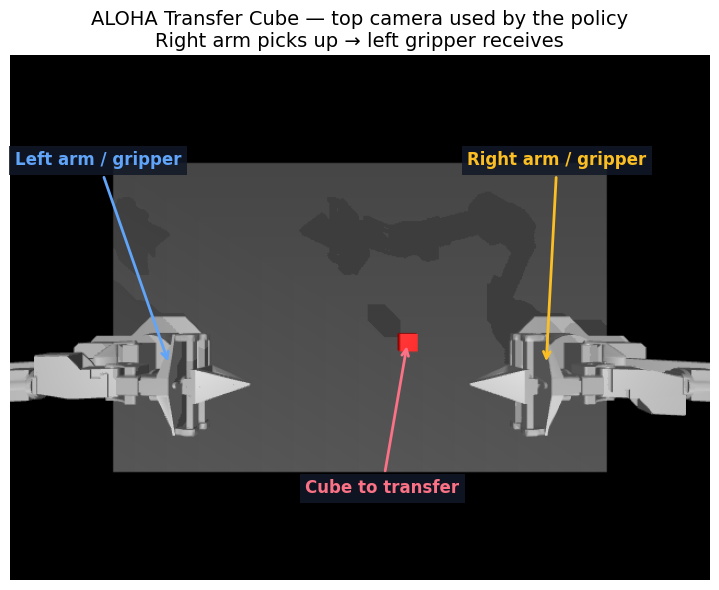

In [7]:
fixture_observations, fixture_batches = [], []
env = make_env()
try:
    for seed in (0, 1, 2):
        obs, _ = env.reset(seed=seed)
        fixture_observations.append(copy.deepcopy(obs))
        fixture_batches.append(normalize_observation(obs, stats))
finally:
    close_env(env)
scene_figure(fixture_observations[0]['pixels']['top']); plt.show()

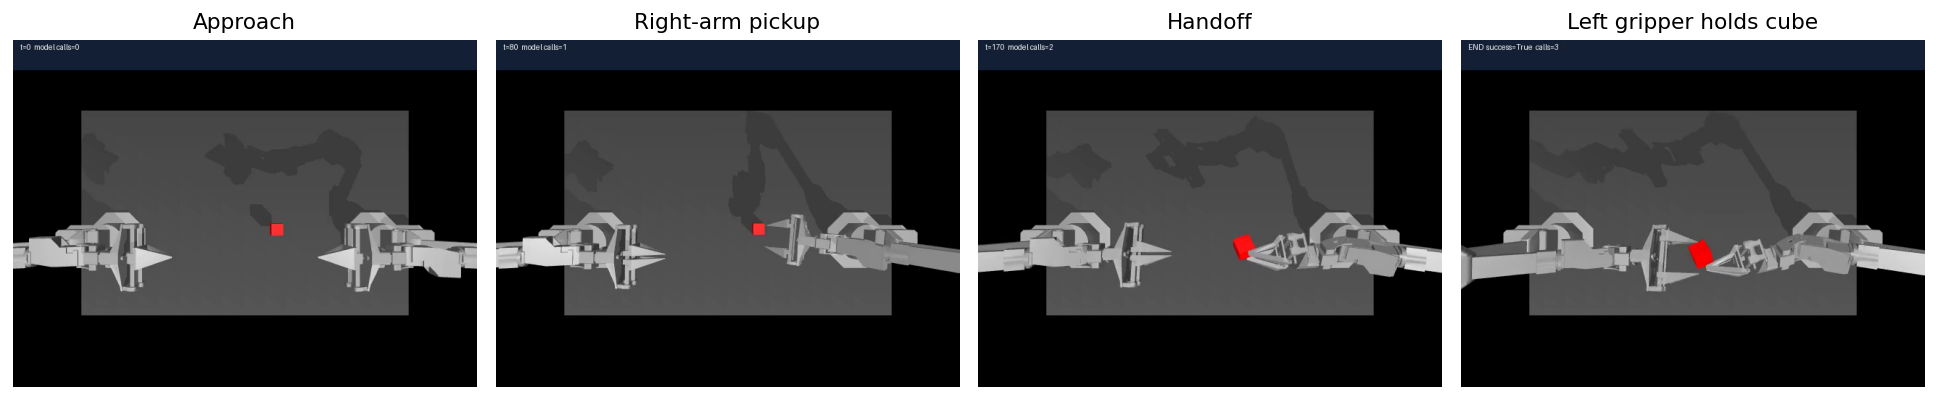

Reference rollout, seed 0, K=100. These are simulated frames captured during preparation, not student results.

## Exercise 1 — Assemble ACT’s action prediction head
### A. Theory: what makes these outputs *actions*?

Each learned query identifies one future time slot. The decoder combines these queries
with observation memory and predicts all H actions in parallel.

`zeros + queries + memory → decoder → shared Linear(D,14) → action chunk`

| Tensor | Shape in this implementation |
|---|---|
| Memory and its positions | `[N,B,D]`, `[N,1,D]` |
| Zero decoder content | `[H,B,D]` |
| Learned query positions | `[H,1,D]` |
| Decoded features | `[B,H,D]` after transpose |
| Normalized actions | `[B,H,14]` |

Here `H=100`, `D=512`. Queries are separate from initial content. Each slot emits a full
robot command through the same linear layer. Inference uses `z=0`; expert actions are only
used by the CVAE posterior during training.

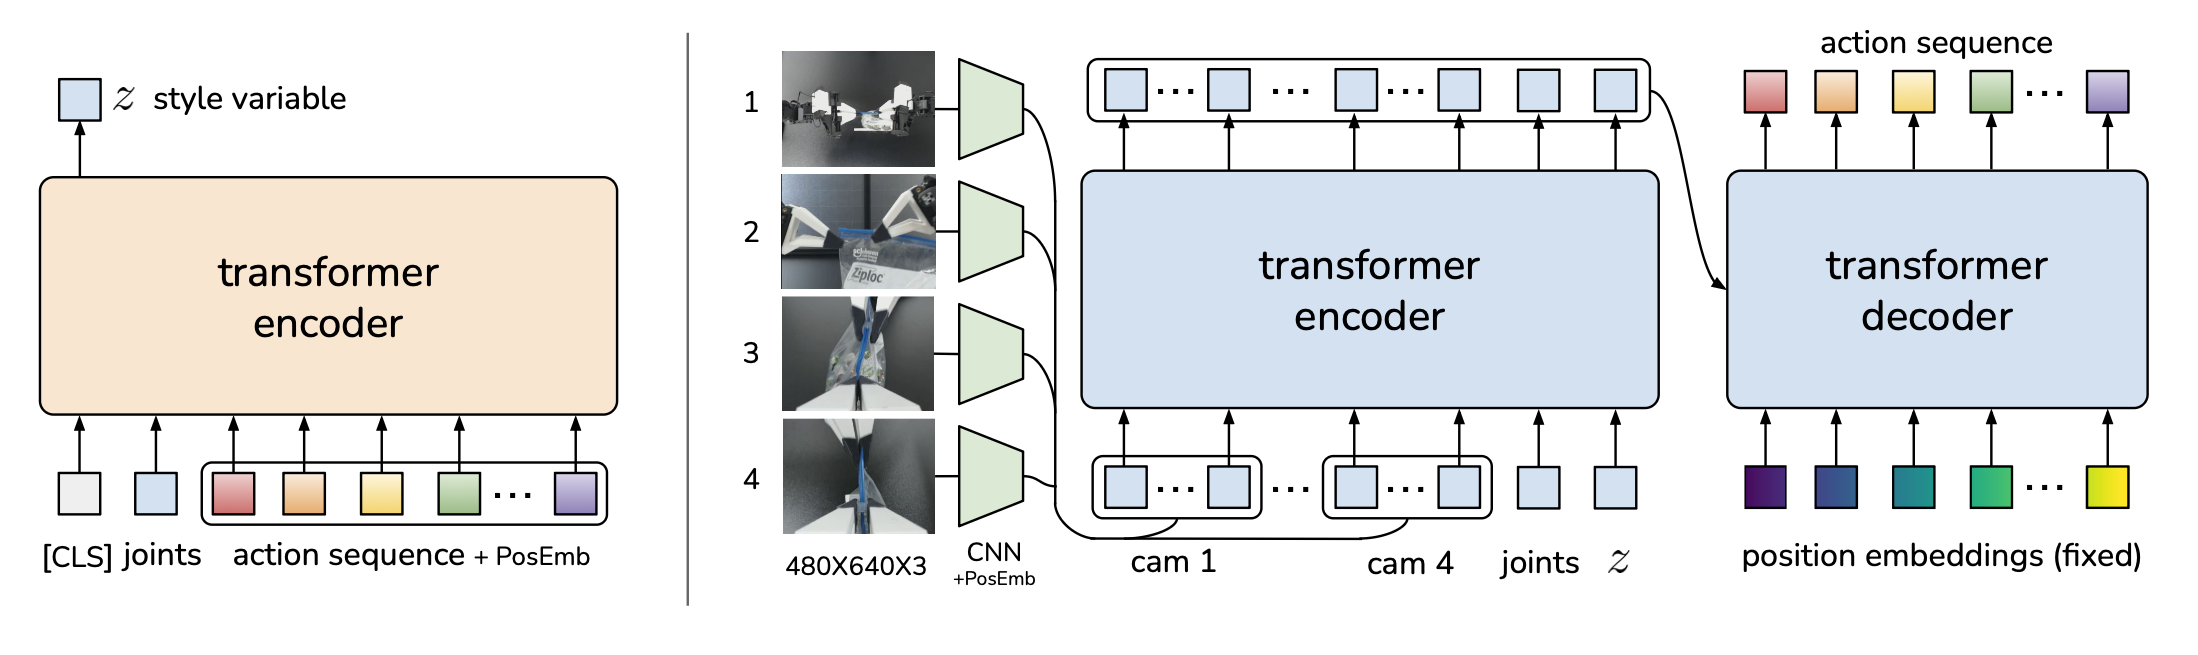

ACT: visual and robot-state tokens become a parallel sequence of joint-space targets.

### B. Task visualization
Each query represents one future step and produces all 14 command coordinates.
Inspect the reference chunk below: these are target commands, not measured future states.

Memory: (302, 1, 512) [N,B,D]
Queries: (100, 512) [H,D]
Output: (1, 100, 14) [B,H,14]


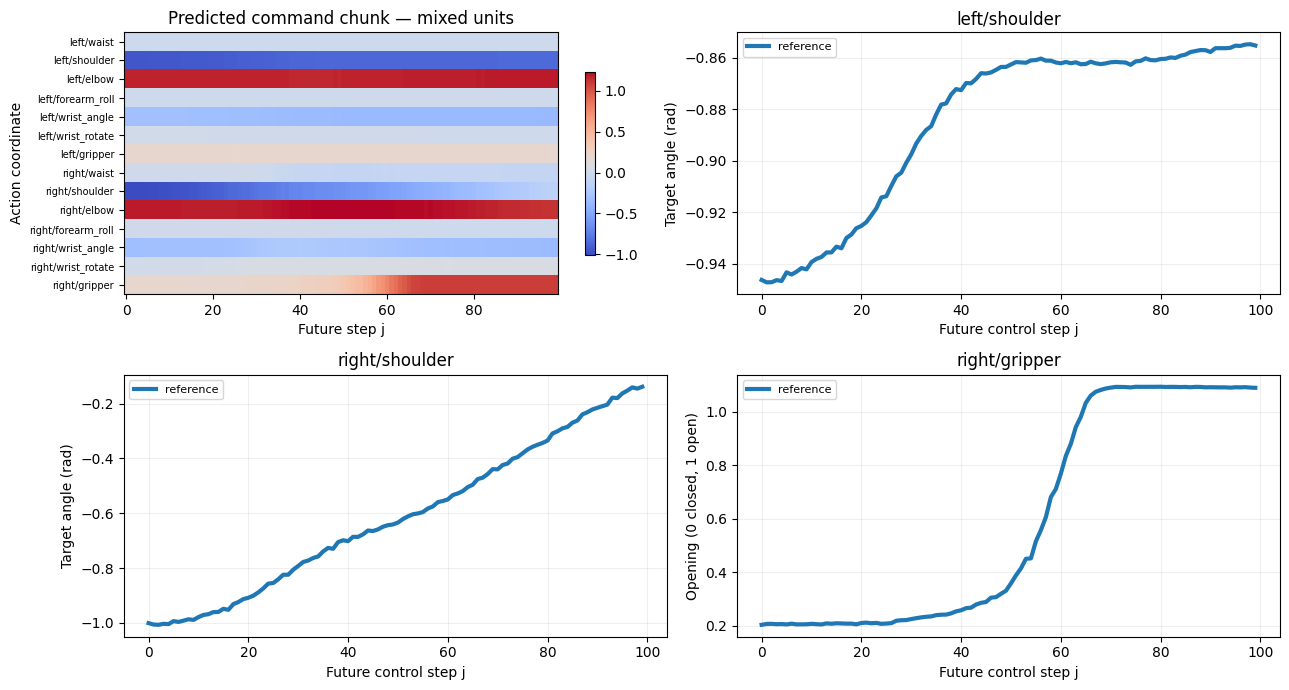

In [8]:
with torch.inference_mode():
    fixture = capture_fixture(model, fixture_batches[0])
    reference_commands = reference_denormalize(fixture['normalized'], stats)
print('Memory:', tuple(fixture['memory'].shape), '[N,B,D]')
print('Queries:', tuple(model.decoder_pos_embed.weight.shape), '[H,D]')
print('Output:', tuple(reference_commands.shape), '[B,H,14]')
chunk_figure(reference_commands); plt.show()

### C. TODO 1.1 — Decode action slots
Complete `forward(memory, memory_positions)`:

1. Create zero content `[H,B,D]` on the memory's device and dtype.
2. Pass learned queries `[H,1,D]` as decoder positions, separately from content.
3. Call the supplied decoder with memory and its positions.
4. Transpose `[H,B,D]` to `[B,H,D]`, apply the shared projection, and return `(features, actions)`.

In [9]:
class StudentACTActionHead(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.decoder = model.decoder          # supplied, with pretrained weights
        self.queries = model.decoder_pos_embed # [H,D] learned time-slot embeddings
        self.projection = model.action_head   # shared Linear(D,14)

    def forward(self, memory, memory_positions):
        # TODO 1: separate zero content [H,B,D] from positional queries [H,1,D].
        # TODO 2: call the supplied decoder, then transpose to [B,H,D].
        # TODO 3: apply the same projection to each slot; return (features, normalized_chunk).
        # Decoder signature: decoder(x, encoder_out, decoder_pos_embed=..., encoder_pos_embed=...)
        h, d = self.queries.weight.shape
        x = memory.new_zeros(h, memory.shape[1], d)
        f = self.decoder(x, memory, encoder_pos_embed=memory_positions,
                         decoder_pos_embed=self.queries.weight[:, None]).transpose(0, 1)
        return f, self.projection(f)

### TODO 1.2 — Denormalize actions
Implement `a = a_normalized * std + mean` using checkpoint statistics.
Preserve `[B,H,14]` and coordinate order; grippers remain opening values.

In [10]:
def student_denormalize(normalized, stats):
    # TODO: invert training normalization independently for each of the 14 coordinates.
    # Keys: 'unnormalize_outputs.buffer_action.mean' and '.std'.
    # Broadcasting should work for any batch size and prediction horizon.
    return normalized * stats['unnormalize_outputs.buffer_action.std'] + stats['unnormalize_outputs.buffer_action.mean']

### Check
Compare features, normalized actions, and commands with the reference on three observations.
Both paths use identical weights, `eval()`, FP32, and `z=0`.

If needed, set `USE_REFERENCE_HEAD=True` to skip Exercise 1 and continue.
Label this fallback in your report.

,fixture,stage,max_absolute_error
0,0,features,0.0
1,0,normalized,0.0
2,0,commands,0.0
3,1,features,0.0
4,1,normalized,0.0
5,1,commands,0.0
6,2,features,0.0
7,2,normalized,0.0
8,2,commands,0.0


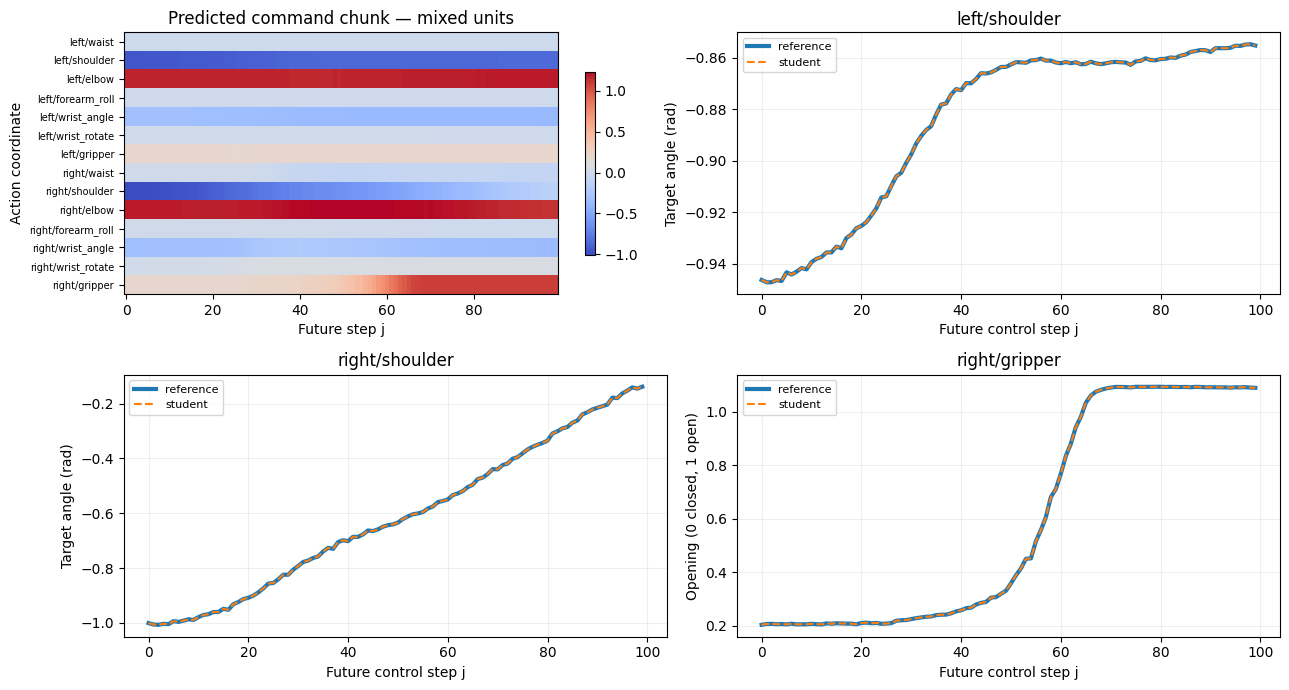

In [11]:
USE_REFERENCE_HEAD = False
if USE_REFERENCE_HEAD:
    active_head = ReferenceHead(model).eval()
    active_denormalize = reference_denormalize
    HEAD_LABEL = 'reference-fallback'
    print('EXERCISE 1 SKIPPED: using the supplied reference head.')
else:
    active_head = StudentACTActionHead(model).eval()
    active_denormalize = student_denormalize
    HEAD_LABEL = 'reconstructed-head'
    errors = check_head(model, stats, active_head, active_denormalize, fixture_batches)
    display(errors)
predict = make_predictor(model, stats, active_head, active_denormalize)
# Numerical equivalence includes the encoder path exposed for head substitution.
with torch.inference_mode():
    features, normalized = active_head(fixture['memory'], fixture['positions'])
    commands = active_denormalize(normalized, stats)
chunk_figure(reference_commands, commands); plt.show()

### Run the policy
The supplied controller executes full chunks. Run the handoff and inspect the video.
Numerical agreement and task success are separate checks.

In [12]:
class DemoController:
    def reset(self): self.queue = deque()
    def select(self, observation, predict):
        if not self.queue: self.queue.extend(predict(observation))
        return self.queue.popleft()

demo_path = RESULTS / 'exercise1_handoff.mp4'
demo_result, demo_trace = run_episode(predict, DemoController(), seed=0, video_path=demo_path)
display(pd.DataFrame([demo_result]))
display(Video(str(demo_path), embed=True, width=640))

,seed,perturb,perturb_dx,success,steps,reward_sum,max_reward,model_calls,inference_seconds,wall_seconds,arm_variation,gripper_variation,feedback_delay_steps
0,0,False,0.0,True,228,153.0,4.0,3,0.032192,1.927117,0.002761,0.006667,None


### Questions

1. What does action query j represent?

   *Your answer:* …
   It is action for timestep j within chunk size of N. In the beginning trained vector of position j

2. Why do fixed queries produce scene-dependent actions?

   *Your answer:* …
   Because keys come from encoder (scene image, robot joints, scene state). Thus, we condition actions on scene

3. What would happen to the predicted action chunk if all query embeddings were identical? Why?

   *Your answer:* …
   They probably will be the same, as the keys are the same for every query vector. In general depens on masking too.

4. How does ACT generate a chunk differently from the flow head in Seminar 03?

   *Your answer:* …
   ACT predicts actions in parallel and in single forward pass (TL DR not a flow-matching policy)

5. What does numerical agreement with the reference prove?

   *Your answer:* …
   That my implementation is correct

## Exercise 2 — Choose how often to replan
### A. Theory and implementation contract

**H** is the number of predicted actions; **K** is the number executed before replanning.
Keep `H=100` and vary `K`. After K steps, use a fresh observation and discard the unused suffix.

For T control steps, model calls are approximately `ceil(T/K)`. Larger K saves calls but
uses older observations longer. `K=1` still uses a model trained on chunks.

### B. Task visualization
The same robot performs the same handoff. Blue shows the prediction, green the executed prefix,
and purple lines the policy calls. Control remains at 50 Hz.

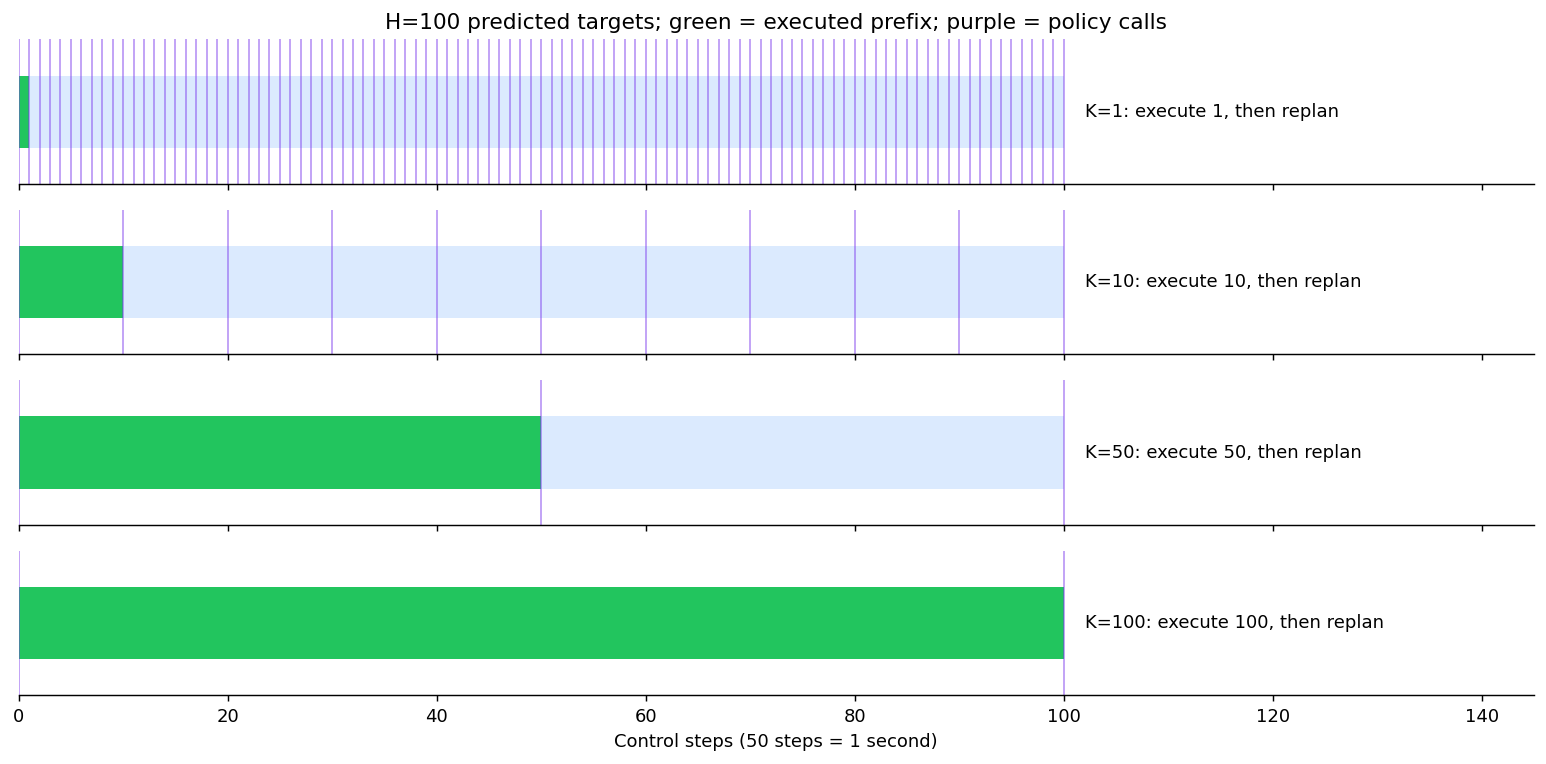

Prediction horizon H stays at 100. Execution horizon K changes how soon a fresh image can affect control.

### C. TODO 2 — Action queue
Complete `select()`:

1. Predict only when the queue is empty.
2. Enqueue the first `K` actions and discard the rest; reject `K>H`.
3. Return one action per step. Use the supplied `reset()` between episodes.

In [13]:
class ChunkController:
    def __init__(self, execution_horizon):
        if execution_horizon < 1:
            raise ValueError('K must be positive')
        self.k = execution_horizon
        self.reset()

    def reset(self):
        self.queue = deque()

    def select(self, observation, predict):
        # TODO: when empty, predict and enqueue only the first K actions.
        # Return one action per call. Never refill while queued actions remain.
        # Reject K > H. reset() above clears the queue between episodes.
        if not self.queue:
            chunk = predict(observation)
            H = len(chunk)
            if self.k > H:
                raise ValueError('K > H')
            
            self.queue.extend(chunk[:self.k])
        return self.queue.popleft()

In [14]:
check_queue(ChunkController)

Queue: execution prefix, replanning, K=1, reset passed.


### Compare K = 1, 10, 50, 100
Use the same three seeds. Compare success counts, model calls, inference time, and videos.
Three episodes give an exploratory comparison.

Results are cached in `seminar04_runs/`. Use `FORCE_RERUN=True` after changing helpers or dependencies.

K1 0 success= False calls= 400
K1 1 success= False calls= 400
K1 2 success= False calls= 400
K10 0 success= False calls= 40
K10 1 success= False calls= 40
K10 2 success= True calls= 36
K50 0 success= True calls= 5
K50 1 success= True calls= 7
K50 2 success= True calls= 6
K100 0 success= True calls= 3
K100 1 success= True calls= 3
K100 2 success= True calls= 3


,successes,episodes,mean_steps,mean_calls,inference_s,wall_s,arm_variation,gripper_variation,feedback_delay
setting,,,,,,,,,
K1,0,3,400.000000,400.000000,3.801691,6.497327,0.000239,0.000313,NaN
K10,1,3,384.000000,38.666667,0.370732,2.982883,0.002145,0.003827,NaN
K50,3,3,263.333333,6.000000,0.053015,1.895894,0.002893,0.006503,NaN
K100,3,3,255.333333,3.000000,0.029826,1.856726,0.002812,0.006083,NaN


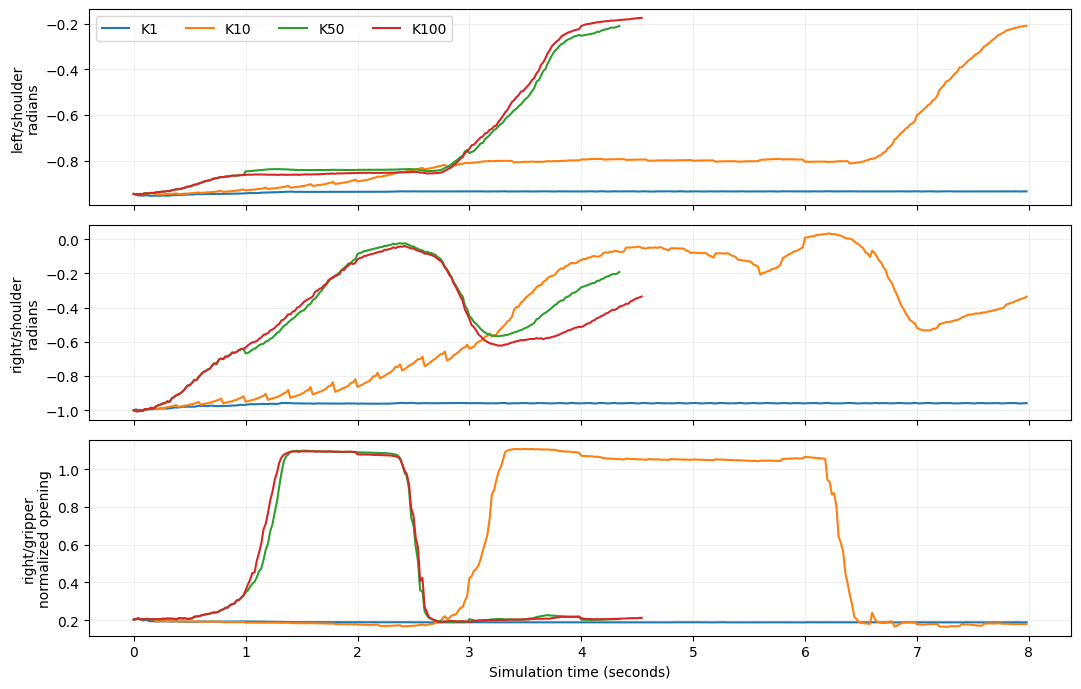

In [15]:
SEEDS = [0, 1, 2]
FORCE_RERUN = False
K_VALUES = [1, 10, 50, 100]
queue_factories = {f'K{k}': (lambda k=k: ChunkController(k)) for k in K_VALUES}
queue_tag = implementation_tag(HEAD_LABEL+'-queue', active_head.forward, active_denormalize, ChunkController.select)
queue_results, queue_traces = evaluate_grid(predict, queue_factories, SEEDS, queue_tag, force=FORCE_RERUN)
display(summary_table(queue_results))
plot_commands(queue_traces, SEEDS[0], list(queue_factories))
show_saved_videos(queue_tag, ['K1','K100'], SEEDS[0])

### Perturbation
At step 20, shift the ungrasped cube +7 cm along world x.
Compare `K=1` and `K=100`.

**Feedback delay** counts steps until the next model call uses the changed scene;
it is not physical recovery time.

K1 0 success= False calls= 400
K100 0 success= False calls= 4


,successes,episodes,mean_steps,mean_calls,inference_s,wall_s,arm_variation,gripper_variation,feedback_delay
setting,,,,,,,,,
K1,0,1,400.0,400.0,3.687152,6.583568,0.000216,0.000377,0.0
K100,0,1,400.0,4.0,0.033440,3.048090,0.003237,0.009813,80.0


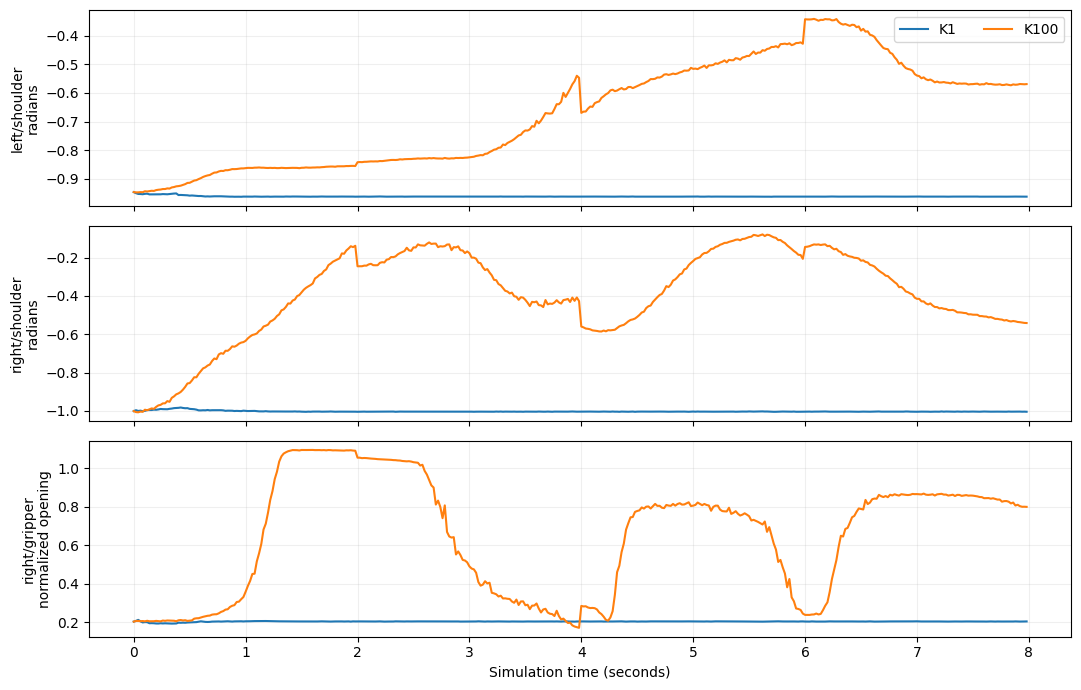

In [16]:
perturb_factories = {name:queue_factories[name] for name in ('K1','K100')}
perturb_results, perturb_traces = evaluate_grid(predict, perturb_factories, [SEEDS[0]], queue_tag,
                                               perturb=True, force=FORCE_RERUN)
display(summary_table(perturb_results))
plot_commands(perturb_traces, SEEDS[0], list(perturb_factories))
show_saved_videos(queue_tag, ['K1','K100'], SEEDS[0], perturb=True)

### Questions

1. How did K affect success, model calls, and inference time?

   *Your answer:* … With higher K SR is higher, less model calls and smaller inference time

2. Why is K=1 not a separately trained single-step BC model?

   *Your answer:* … Because we just call the inference of the same H=100 model, but only execute first action and replan

3. What is the feedback delay in seconds after the perturbation at step 20 for K=1 and K=100? Use the 50 Hz control rate.

   *Your answer:* … For K=1 it is obviously 0. For K=100 at 50Hz (100 - 20) / 50 = 1.6 seconds

4. What changes in the scene during the perturbation? Compare the K=1 and K=100 videos: how do the arms respond, and does the handoff succeed?

   *Your answer:* … K=1 is almost static in every step, while K=100 looks like doing replaning, but eventually fails (I guess do to OOD that it never saw failures, and thus cannot replan)

5. Can these experiments establish the effect of training with different chunk lengths?

   *Your answer:* … No. Complete set up should include models trained with different H. Current experiments vary only K which is not enough for fair comparison and correct conclusion.

## Exercise 3 — Combine overlapping forecasts
### A. Theory and implementation contract

At step t, a chunk issued at s contributes entry `t−s`. Combine only forecasts
for the same execution time:

`action = sum(w[i] * prediction[i]) / sum(w[i])`, with `w[i] = exp(-m*i)`.

Index 0 is the **oldest** valid forecast: m=0 gives equal weights, m>0 favors older,
and m<0 favors newer predictions. Call the model every step; ensembling does not save calls.

### B. Task visualization
For the same handoff, combine forecasts referring to one execution time.
The highlighted column selects those forecasts; the curves show their weights.

![Temporal alignment is the essential operation: select chunk[t−s] for each issue time s.](attachment:ensemble_figure.png)

Temporal alignment is the essential operation: select chunk[t−s] for each issue time s.
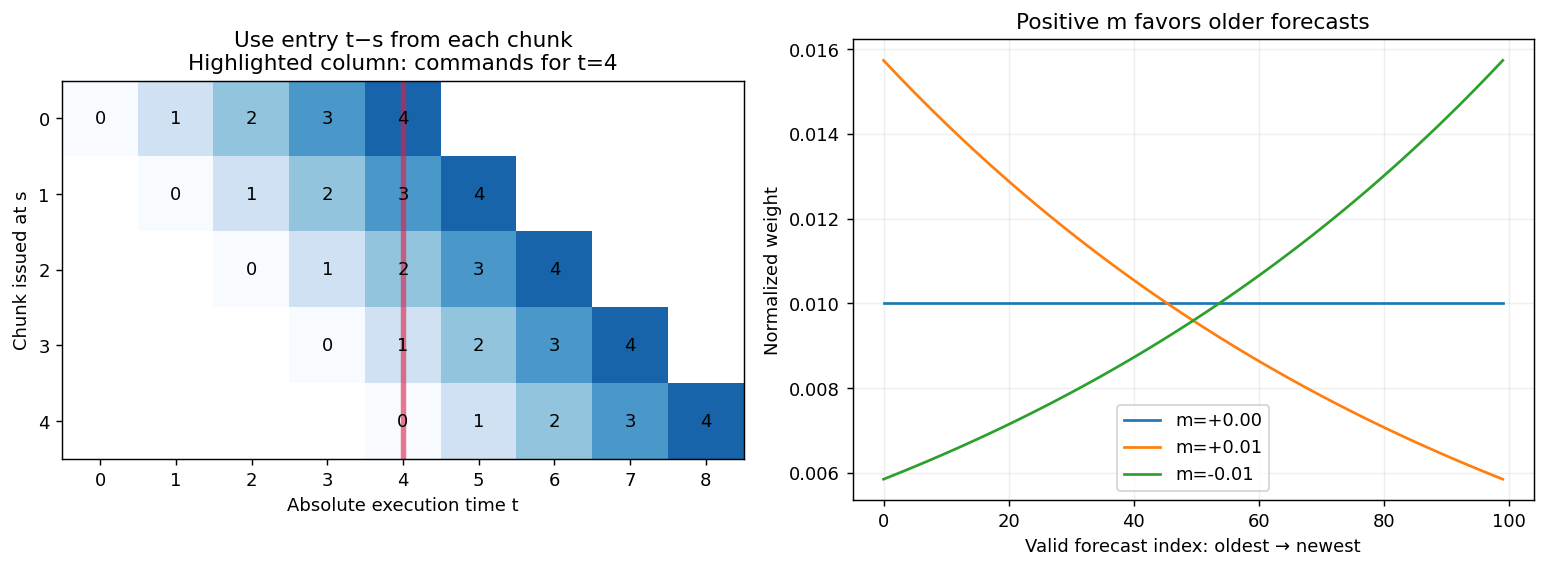

### C. TODO 3 — Temporal ensemble
Complete `update(chunk)`:

1. Store `(issue_time, chunk)` and remove expired chunks.
2. Select `chunk[t-s]` from each chunk issued at `s`.
3. Average with normalized `exp(-m*i)` weights, oldest first.
4. Advance time. Clear history on reset; do not modify input chunks.

Check: chunks `[0,1,2]`, `[10,11,12]`, `[20,21,22]` issued at steps 0,1,2
contribute `2,11,20` at step 2. Their uniform average is 11.

In [17]:
class TemporalEnsembler:
    def __init__(self, horizon, coefficient):
        self.horizon = horizon
        self.coefficient = coefficient
        self.reset()

    def reset(self):
        self.time = 0
        self.history = deque()

    def update(self, chunk):
        # TODO: store (issue_time, chunk), discard expired chunks,
        # select chunk[current_time - issue_time] from each valid chunk,
        # compute normalized exp(-m*i) weights in OLDEST-to-NEWEST order,
        # return one action and advance self.time. Do not modify the input array.
        self.history.append((self.time, chunk.copy()))
        if self.time - self.history[0][0] >= self.horizon:
            self.history.popleft()

        predictions = np.stack([past_chunk[self.time - issue_time] 
                                for issue_time, past_chunk in self.history])
        weights = np.exp(-self.coefficient * np.arange(len(self.history)))
        weights = weights / weights.sum()

        action = (predictions * weights[:, None]).sum(axis=0)
        self.time += 1
        return action

In [18]:
check_ensemble(TemporalEnsembler)

Ensembling: time alignment, weights, startup, expiration, reset and reference parity passed.


### Run ensembling
The adapter calls the model every step and averages denormalized commands.
Compare no ensembling, equal weights, older-weighted, and newer-weighted forecasts.

In [19]:
class EnsembleController:
    def __init__(self, horizon, coefficient, ensembler_class):
        self.ensemble = ensembler_class(horizon, coefficient)

    def reset(self):
        self.ensemble.reset()

    def select(self, observation, predict):
        return self.ensemble.update(predict(observation))

no_ensemble 0 success= False calls= 400
no_ensemble 1 success= False calls= 400
no_ensemble 2 success= False calls= 400
uniform 0 success= False calls= 400
uniform 1 success= True calls= 292
uniform 2 success= True calls= 277
older 0 success= False calls= 400
older 1 success= True calls= 281
older 2 success= True calls= 277
newer 0 success= False calls= 400
newer 1 success= True calls= 304
newer 2 success= True calls= 280


,successes,episodes,mean_steps,mean_calls,inference_s,wall_s,arm_variation,gripper_variation,feedback_delay
setting,,,,,,,,,
no_ensemble,0,3,400.000000,400.000000,3.652505,6.324705,0.000239,0.000313,NaN
uniform,2,3,323.000000,323.000000,2.740781,5.126597,0.002130,0.005061,NaN
older,2,3,319.333333,319.333333,3.030192,5.285723,0.002236,0.005326,NaN
newer,2,3,328.000000,328.000000,3.159192,5.525970,0.002080,0.004976,NaN


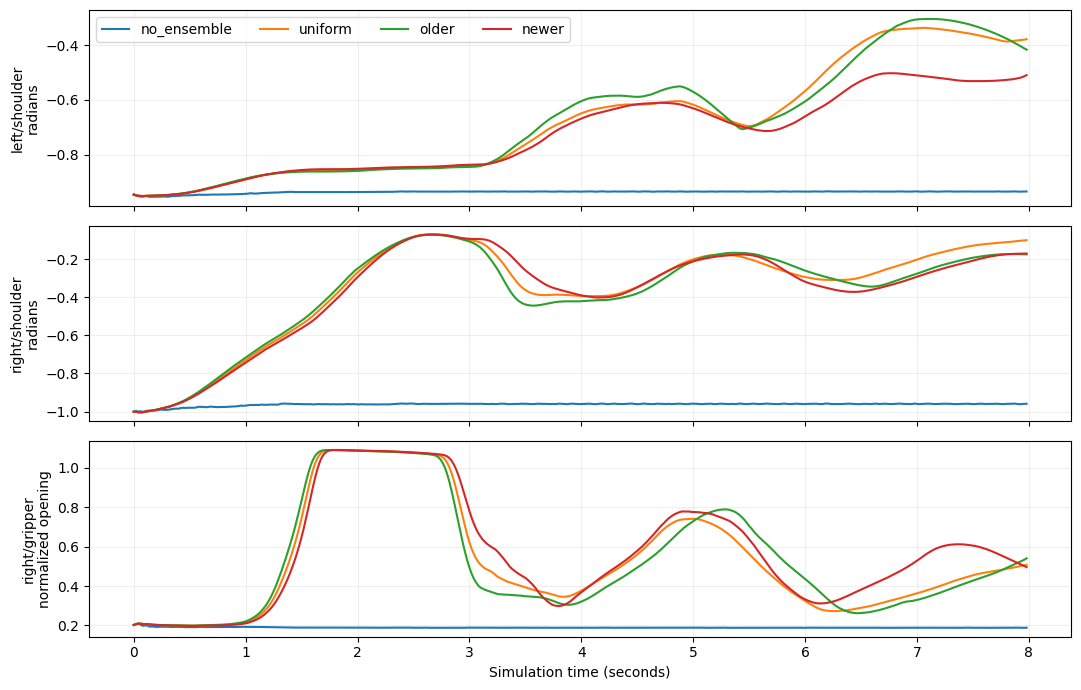

In [20]:
ensemble_factories = {
    'no_ensemble':lambda: ChunkController(1),
    'uniform':lambda: EnsembleController(100, 0., TemporalEnsembler),
    'older':lambda: EnsembleController(100, .01, TemporalEnsembler),
    'newer':lambda: EnsembleController(100, -.01, TemporalEnsembler),
}
ensemble_tag = implementation_tag(HEAD_LABEL+'-ensemble', active_head.forward, active_denormalize,
                                  ChunkController.select, TemporalEnsembler.update)
ensemble_results, ensemble_traces = evaluate_grid(predict, ensemble_factories, SEEDS, ensemble_tag,
                                                 force=FORCE_RERUN)
display(summary_table(ensemble_results))
plot_commands(ensemble_traces, SEEDS[0], list(ensemble_factories))
show_saved_videos(ensemble_tag, ['no_ensemble','older'], SEEDS[0])

### Perturbation and smoothness
Repeat the same cube displacement. Compare success and mean absolute command change per step,
separately for arm angles and gripper openings. Smoother commands do not guarantee success.

no_ensemble 0 success= False calls= 400
uniform 0 success= True calls= 344
older 0 success= True calls= 337
newer 0 success= True calls= 347


,successes,episodes,mean_steps,mean_calls,inference_s,wall_s,arm_variation,gripper_variation,feedback_delay
setting,,,,,,,,,
no_ensemble,0,1,400.0,400.0,3.683553,6.623517,0.000216,0.000377,0.0
uniform,1,1,344.0,344.0,3.189004,5.891438,0.002092,0.004846,0.0
older,1,1,337.0,337.0,3.140750,5.832602,0.002080,0.004838,0.0
newer,1,1,347.0,347.0,3.211547,5.959112,0.002116,0.004802,0.0


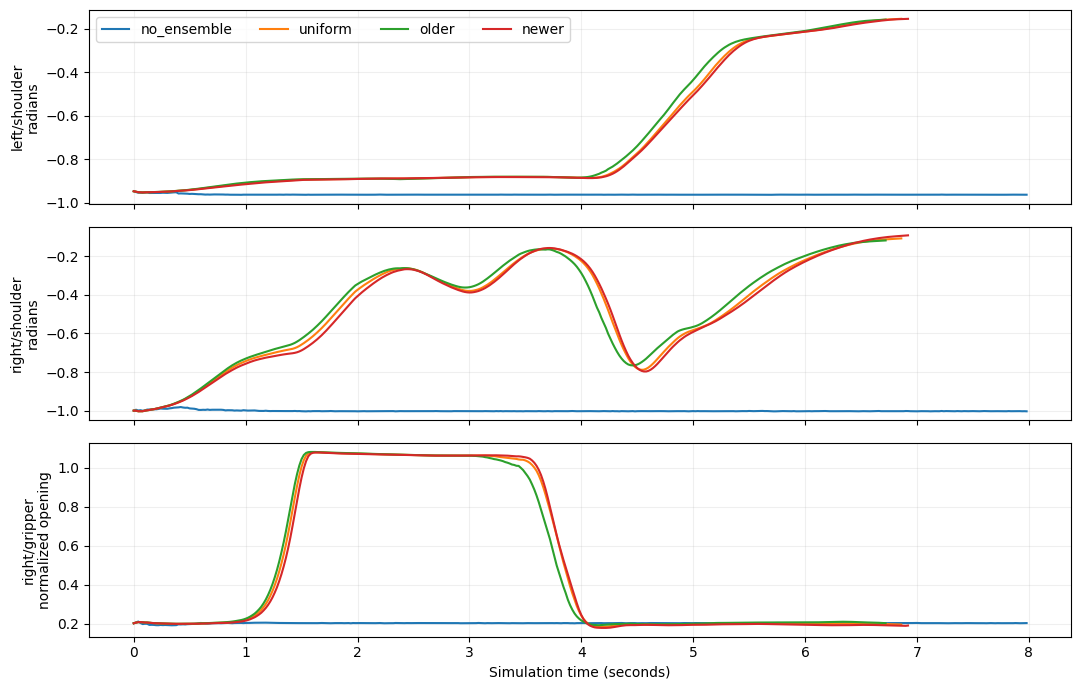

In [21]:
ensemble_perturbed, ensemble_perturbed_traces = evaluate_grid(
    predict, ensemble_factories, [SEEDS[0]], ensemble_tag, perturb=True, force=FORCE_RERUN)
display(summary_table(ensemble_perturbed))
plot_commands(ensemble_perturbed_traces, SEEDS[0], list(ensemble_factories))
show_saved_videos(ensemble_tag, ['older','newer'], SEEDS[0], perturb=True)

### Questions

1. Why must each stored chunk contribute entry t−s?

   *Your answer:* … Because each chunk was generated in different times. Thus, to get same physical time, we need to use different timesteps within chunks

2. Which sign of m favors older forecasts?

   *Your answer:* … m > 0

3. Did smoother commands improve success in your runs?

   *Your answer:* … Compared to K = 1 yes, 0 / 3 vs 2 / 3. Compared to K=100 3 / 3 vs 2 / 3, no. It made it little bit worse

4. Why does this ensemble not reduce model calls?

   *Your answer:* … Because we call model at every timestep as in K=1

5. How does this differ from smoothing executed actions?

   *Your answer:* … Smoothing adds actions from previous chunk while planning, this approach sums them with weights

## Sources
- [ACT paper](https://arxiv.org/abs/2304.13705) · [Original code](https://github.com/tonyzhaozh/act).
- [Checkpoint](https://huggingface.co/lerobot/act_aloha_sim_transfer_cube_human/tree/ba73b2766f1371cdc133ca4efb97eb090d744625).
- [Pinned LeRobot source](https://github.com/huggingface/lerobot/blob/3c0a209f9fac4d2a57617e686a7f2a2309144ba2/lerobot/common/policies/act/modeling_act.py).
- [gym-aloha](https://github.com/huggingface/gym-aloha), version 0.1.4.

ACT source: Copyright 2024 Tony Z. Zhao and The HuggingFace Inc. team,
[Apache-2.0](https://www.apache.org/licenses/LICENSE-2.0). Attribution is retained in the code.
Figures and exercises are seminar-specific; reference frames come from simulation.